# Imports

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import sys
sys.path.append('/kaggle/usr/lib/airline_customer_satisfaction_common/')  
import airline_customer_satisfaction_common
from airline_customer_satisfaction_common import CustomRename, CustomImputer, CustomFeatureCreator, CustomEncoder, CustomScaler


import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
import pylab

import math
import datetime

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

input_file_path='/kaggle/input/airline-csv/'

import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(filename='airline_satisfaction_logistic_regression.log',
                    filemode='a',
                    format='%(asctime)s,%(msecs)03d %(name)s %(levelname)s %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    level=logging.DEBUG)

# Creating an object
logger = logging.getLogger()

# Setting the threshold of logger to DEBUG
logger.setLevel(logging.DEBUG)

In [3]:
#load dataset
df_original = pd.read_csv(input_file_path+"Invistico_Airline.csv")

In [4]:
df_original.info()
df_original.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


# Clean data, transform data

* Plan A: drop rows which have missing values
    * According to EDA, we know that 393 rows have missing values, 0.3% of total, we could delete them
* Plan B: drop cols which have missing values
    * According to EDA, we know that departure_delay_in_minutes and arrival_delay_in_minutes are correlated<BR/>
      Logistic regression need to meet no multicollinearity assumption, we could use one of them

Reference:
* [How To Write Clean And Scalable Code With Custom Transformers & Sklearn Pipelines](https://medium.com/@benlc77/how-to-write-clean-and-scalable-code-with-custom-transformers-sklearn-pipelines-ecb8e53fe110)
* [Missing value imputation using Sklearn pipelines](https://marloz.github.io/projects/sklearn/pipeline/missing/preprocessing/2020/03/20/sklearn-pipelines-missing-values.html)
* [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)
* [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [5]:
############################################################
# Clean data, transform data
# Plan A
############################################################
data_process_pipeline = Pipeline(
    steps=[
        ('rename_features',CustomRename()),
        ("impute_features", CustomImputer(missing_values = np.nan, 
                        strategy ='drop_row')),   
        ('create_new_features',CustomFeatureCreator()),   
    ]
)
data_process_pipeline=data_process_pipeline.fit(df_original)
df_trans_drop_row=data_process_pipeline.transform(df_original)
print(df_trans_drop_row.shape)
df_trans_drop_row.head(10)

(129487, 45)


,satisfaction,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,departure_delay_in_hours,departure_delay_class,arrival_delay_in_hours,arrival_delay_class,flight_distance_range,flight_distance_class,age_range,age_class_by_airline,seat_comfort_class,departure_arrival_time_convenient_class,food_and_drink_class,gate_location_class,inflight_wifi_service_class,inflight_entertainment_class,online_support_class,ease_of_online_booking_class,on_board_service_class,leg_room_service_class,baggage_handling_class,checkin_service_class,cleanliness_class,online_boarding_class,class_m
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,0.0,No Delay,0.0,No Delay,<1K,Short-Haul,"[60,70)",Senior,Low,Low,Low,Median,Median,High,Median,Median,Median,Low,Median,High,Median,Median,Eco&EcoPlus
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0,5.0,Significant Delay,5.0,Significant Delay,"[1K,3K)",Medium-Haul,"[40,50)",Adult,Low,Low,Low,Median,Low,Median,Median,Median,High,High,High,Median,Median,Median,Business
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,0.0,No Delay,0.0,No Delay,"[1K,3K)",Medium-Haul,"[10,20)",Young-Adult,Low,Low,Low,Median,Median,Low,Median,Median,Median,Median,High,High,High,Median,Eco&EcoPlus
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,0.0,No Delay,0.0,No Delay,<1K,Short-Haul,"[60,70)",Adult,Low,Low,Low,Median,Median,High,Median,Low,Low,Low,Low,High,Low,Median,Eco&EcoPlus
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,0.0,No Delay,0.0,No Delay,<1K,Short-Haul,>=70,Senior,Low,Low,Low,Median,High,Median,High,Median,Median,Low,Median,High,Median,High,Eco&EcoPlus
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,2,0,2,2,5,4,5,5,4,2,0,0.0,0.0,No Delay,0.0,No Delay,"[1K,3K)",Medium-Haul,"[30,40)",Adult,Low,Low,Low,Median,Median,Low,Median,Median,High,High,High,High,High,Median,Eco&EcoPlus
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,2,5,5,5,5,0,5,5,5,3,17,15.0,0.0,Minor Delay,0.0,Minor Delay,<1K,Short-Haul,"[60,70)",Senior,Low,Low,Low,Median,Median,High,High,High,High,Low,High,High,High,Median,Eco&EcoPlus
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,2,0,2,2,3,3,4,5,4,2,0,0.0,0.0,No Delay,0.0,No Delay,"[1K,3K)",Medium-Haul,"[10,20)",Children,Low,Low,Low,Median,Median,Low,Median,Median,Median,Median,High,High,High,Median,Eco&EcoPlus
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,5,3,5,4,4,0,1,5,4,4,0,0.0,0.0,No Delay,0.0,No Delay,<1K,Short-Haul,"[50,60)",Adult,Low,Low,Low,Median,High,Median,High,High,High,Low,Low,High,High,High,Business
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,2,0,2,2,2,4,5,3,4,2,30,26.0,0.0,Minor Delay,0.0,Minor Delay,"[1K,3K)",Medium-Haul,"[20,30)",Adult,Low,Low,Low,Median,Median,Low,Median,Median,Median,High,High,Median,High,Median,Eco&EcoPlus


In [6]:
############################################################
# Clean data, transform data
# Plan B
############################################################
data_process_pipeline = Pipeline(
    steps=[
        ('rename_features',CustomRename()),
        ("impute_features", CustomImputer(missing_values = np.nan, 
                        strategy ='drop_col')),   
        ('create_new_features',CustomFeatureCreator()),   
    ]
)
data_process_pipeline=data_process_pipeline.fit(df_original)
df_trans_drop_col=data_process_pipeline.transform(df_original)
print(df_trans_drop_col.shape)
df_trans_drop_col.head(10)

(129880, 42)


,satisfaction,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,departure_delay_in_hours,departure_delay_class,flight_distance_range,flight_distance_class,age_range,age_class_by_airline,seat_comfort_class,departure_arrival_time_convenient_class,food_and_drink_class,gate_location_class,inflight_wifi_service_class,inflight_entertainment_class,online_support_class,ease_of_online_booking_class,on_board_service_class,leg_room_service_class,baggage_handling_class,checkin_service_class,cleanliness_class,online_boarding_class,class_m
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,No Delay,<1K,Short-Haul,"[60,70)",Senior,Low,Low,Low,Median,Median,High,Median,Median,Median,Low,Median,High,Median,Median,Eco&EcoPlus
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,5.0,Significant Delay,"[1K,3K)",Medium-Haul,"[40,50)",Adult,Low,Low,Low,Median,Low,Median,Median,Median,High,High,High,Median,Median,Median,Business
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,No Delay,"[1K,3K)",Medium-Haul,"[10,20)",Young-Adult,Low,Low,Low,Median,Median,Low,Median,Median,Median,Median,High,High,High,Median,Eco&EcoPlus
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,No Delay,<1K,Short-Haul,"[60,70)",Adult,Low,Low,Low,Median,Median,High,Median,Low,Low,Low,Low,High,Low,Median,Eco&EcoPlus
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,No Delay,<1K,Short-Haul,>=70,Senior,Low,Low,Low,Median,High,Median,High,Median,Median,Low,Median,High,Median,High,Eco&EcoPlus
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,2,0,2,2,5,4,5,5,4,2,0,0.0,No Delay,"[1K,3K)",Medium-Haul,"[30,40)",Adult,Low,Low,Low,Median,Median,Low,Median,Median,High,High,High,High,High,Median,Eco&EcoPlus
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,2,5,5,5,5,0,5,5,5,3,17,0.0,Minor Delay,<1K,Short-Haul,"[60,70)",Senior,Low,Low,Low,Median,Median,High,High,High,High,Low,High,High,High,Median,Eco&EcoPlus
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,2,0,2,2,3,3,4,5,4,2,0,0.0,No Delay,"[1K,3K)",Medium-Haul,"[10,20)",Children,Low,Low,Low,Median,Median,Low,Median,Median,Median,Median,High,High,High,Median,Eco&EcoPlus
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,5,3,5,4,4,0,1,5,4,4,0,0.0,No Delay,<1K,Short-Haul,"[50,60)",Adult,Low,Low,Low,Median,High,Median,High,High,High,Low,Low,High,High,High,Business
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,2,0,2,2,2,4,5,3,4,2,30,0.0,Minor Delay,"[1K,3K)",Medium-Haul,"[20,30)",Adult,Low,Low,Low,Median,Median,Low,Median,Median,Median,High,High,Median,High,Median,Eco&EcoPlus


### Encode data

* Plan A:
    * Dummy encoding `customer_type` and `type_of_travel`
    * Ordinal encoding `class`,`class_m`,`age_range`,`age_class_by_airline`,`flight_distance_range`,`flight_distance_class`,
`departure_delay_class`,`satisfaction`,
`seat_comfort_class`, `departure_arrival_time_convenient_class`, `food_and_drink_class`,
`gate_location_class`, `inflight_wifi_service_class`,
`inflight_entertainment_class`, `online_support_class`,
`ease_of_online_booking_class`, `on_board_service_class`,
`leg_room_service_class`, `baggage_handling_class`,
`checkin_service_class`, `cleanliness_class`, `online_boarding_class`
* Plan B: drop cols which have missing values
    * Dummy encoding `class`,`class_m`,`age_range`,`age_class_by_airline`,`flight_distance_range`,`flight_distance_class`,`departure_delay_class`, `customer_type`,`type_of_travel`,
`seat_comfort_class`, `departure_arrival_time_convenient_class`, `food_and_drink_class`,
`gate_location_class`, `inflight_wifi_service_class`,
`inflight_entertainment_class`, `online_support_class`,
`ease_of_online_booking_class`, `on_board_service_class`,
`leg_room_service_class`, `baggage_handling_class`,
`checkin_service_class`, `cleanliness_class`, `online_boarding_class`,
`seat_comfort`, `departure_arrival_time_convenient`,
`food_and_drink`, `gate_location`, `inflight_wifi_service`,
`inflight_entertainment`, `online_support`, `ease_of_online_booking`,
`on_board_service`, `leg_room_service`, `baggage_handling`,
`checkin_service`, `cleanliness`, `online_boarding`
    * Ordinal encoding `satisfaction`

In [7]:
############################################################
# Encode data
# Plan A: df_trans_drop_row
# Encode data: Plan A
############################################################
ordinal_list=['class','class_m','age_range','age_class_by_airline','flight_distance_range','flight_distance_class',
              'departure_delay_class','satisfaction',
               'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
               'gate_location_class', 'inflight_wifi_service_class',
               'inflight_entertainment_class', 'online_support_class',
               'ease_of_online_booking_class', 'on_board_service_class',
               'leg_room_service_class', 'baggage_handling_class',
               'checkin_service_class', 'cleanliness_class', 'online_boarding_class']
onehot_list=['customer_type','type_of_travel']

data_encode_pipeline = Pipeline(
    steps=[
        ('encode_features',CustomEncoder(ordinal_col_list=ordinal_list,dummy_col_list=onehot_list)), 
    ]
)

data_encode_pipeline=data_encode_pipeline.fit(df_trans_drop_row)
df_encode_aa=data_encode_pipeline.transform(df_trans_drop_row)
print(df_encode_aa.shape)
df_encode_aa.head(10)

(129487, 45)


,satisfaction,age,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,departure_delay_in_hours,departure_delay_class,arrival_delay_in_hours,arrival_delay_class,flight_distance_range,flight_distance_class,age_range,age_class_by_airline,seat_comfort_class,departure_arrival_time_convenient_class,food_and_drink_class,gate_location_class,inflight_wifi_service_class,inflight_entertainment_class,online_support_class,ease_of_online_booking_class,on_board_service_class,leg_room_service_class,baggage_handling_class,checkin_service_class,cleanliness_class,online_boarding_class,class_m,customer_type_dummy_disloyal_customer,type_of_travel_dummy_personal_travel
0,1,65,0,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,0.0,0,0.0,No Delay,0,0,6,4,0,0,0,1,1,2,1,1,1,0,1,2,1,1,0,0,1
1,1,47,2,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0,5.0,3,5.0,Significant Delay,1,1,4,3,0,0,0,1,0,1,1,1,2,2,2,1,1,1,1,0,1
2,1,15,0,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,0.0,0,0.0,No Delay,1,1,1,2,0,0,0,1,1,0,1,1,1,1,2,2,2,1,0,0,1
3,1,60,0,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,0.0,0,0.0,No Delay,0,0,6,3,0,0,0,1,1,2,1,0,0,0,0,2,0,1,0,0,1
4,1,70,0,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,0.0,0,0.0,No Delay,0,0,7,4,0,0,0,1,2,1,2,1,1,0,1,2,1,2,0,0,1
5,1,30,0,1894,0,0,0,3,2,0,2,2,5,4,5,5,4,2,0,0.0,0.0,0,0.0,No Delay,1,1,3,3,0,0,0,1,1,0,1,1,2,2,2,2,2,1,0,0,1
6,1,66,0,227,0,0,0,3,2,5,5,5,5,0,5,5,5,3,17,15.0,0.0,1,0.0,Minor Delay,0,0,6,4,0,0,0,1,1,2,2,2,2,0,2,2,2,1,0,0,1
7,1,10,0,1812,0,0,0,3,2,0,2,2,3,3,4,5,4,2,0,0.0,0.0,0,0.0,No Delay,1,1,1,1,0,0,0,1,1,0,1,1,1,1,2,2,2,1,0,0,1
8,1,56,2,73,0,0,0,3,5,3,5,4,4,0,1,5,4,4,0,0.0,0.0,0,0.0,No Delay,0,0,5,3,0,0,0,1,2,1,2,2,2,0,0,2,2,2,1,0,1
9,1,22,0,1556,0,0,0,3,2,0,2,2,2,4,5,3,4,2,30,26.0,0.0,1,0.0,Minor Delay,1,1,2,3,0,0,0,1,1,0,1,1,1,2,2,1,2,1,0,0,1


In [8]:
############################################################
# Encode data
# Plan A: df_trans_drop_row
# Encode data: Plan B
############################################################

ordinal_list=['satisfaction']

onehot_list=['class','class_m','age_range','age_class_by_airline','flight_distance_range','flight_distance_class','departure_delay_class', 'customer_type','type_of_travel',
               'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
               'gate_location_class', 'inflight_wifi_service_class',
               'inflight_entertainment_class', 'online_support_class',
               'ease_of_online_booking_class', 'on_board_service_class',
               'leg_room_service_class', 'baggage_handling_class',
               'checkin_service_class', 'cleanliness_class', 'online_boarding_class',
               'seat_comfort', 'departure_arrival_time_convenient',
               'food_and_drink', 'gate_location', 'inflight_wifi_service',
               'inflight_entertainment', 'online_support', 'ease_of_online_booking',
               'on_board_service', 'leg_room_service', 'baggage_handling',
               'checkin_service', 'cleanliness', 'online_boarding']

data_encode_pipeline = Pipeline(
    steps=[
        ('encode_features',CustomEncoder(ordinal_col_list=ordinal_list,dummy_col_list=onehot_list)), 
    ]
)
data_encode_pipeline=data_encode_pipeline.fit(df_trans_drop_row)
df_encode_ab=data_encode_pipeline.transform(df_trans_drop_row)
print(df_encode_ab.shape)
df_encode_ab.head(10)

(129487, 128)


,satisfaction,age,flight_distance,departure_delay_in_minutes,arrival_delay_in_minutes,departure_delay_in_hours,arrival_delay_in_hours,arrival_delay_class,customer_type_dummy_disloyal_customer,type_of_travel_dummy_personal_travel,class_dummy_eco,class_dummy_eco_plus,seat_comfort_dummy_1,seat_comfort_dummy_2,seat_comfort_dummy_3,seat_comfort_dummy_4,seat_comfort_dummy_5,departure_arrival_time_convenient_dummy_1,departure_arrival_time_convenient_dummy_2,departure_arrival_time_convenient_dummy_3,departure_arrival_time_convenient_dummy_4,departure_arrival_time_convenient_dummy_5,food_and_drink_dummy_1,food_and_drink_dummy_2,food_and_drink_dummy_3,food_and_drink_dummy_4,food_and_drink_dummy_5,gate_location_dummy_1,gate_location_dummy_2,gate_location_dummy_3,gate_location_dummy_4,gate_location_dummy_5,inflight_wifi_service_dummy_1,inflight_wifi_service_dummy_2,inflight_wifi_service_dummy_3,inflight_wifi_service_dummy_4,inflight_wifi_service_dummy_5,inflight_entertainment_dummy_1,inflight_entertainment_dummy_2,inflight_entertainment_dummy_3,inflight_entertainment_dummy_4,inflight_entertainment_dummy_5,online_support_dummy_1,online_support_dummy_2,online_support_dummy_3,online_support_dummy_4,online_support_dummy_5,ease_of_online_booking_dummy_1,ease_of_online_booking_dummy_2,ease_of_online_booking_dummy_3,ease_of_online_booking_dummy_4,ease_of_online_booking_dummy_5,on_board_service_dummy_1,on_board_service_dummy_2,on_board_service_dummy_3,on_board_service_dummy_4,on_board_service_dummy_5,leg_room_service_dummy_1,leg_room_service_dummy_2,leg_room_service_dummy_3,leg_room_service_dummy_4,leg_room_service_dummy_5,baggage_handling_dummy_2,baggage_handling_dummy_3,baggage_handling_dummy_4,baggage_handling_dummy_5,checkin_service_dummy_1,checkin_service_dummy_2,checkin_service_dummy_3,checkin_service_dummy_4,checkin_service_dummy_5,cleanliness_dummy_1,cleanliness_dummy_2,cleanliness_dummy_3,cleanliness_dummy_4,cleanliness_dummy_5,online_boarding_dummy_1,online_boarding_dummy_2,online_boarding_dummy_3,online_boarding_dummy_4,online_boarding_dummy_5,departure_delay_class_dummy_moderate_delay,departure_delay_class_dummy_no_delay,departure_delay_class_dummy_significant_delay,flight_distance_range_dummy_gte4k,flight_distance_range_dummy_1k_3k,flight_distance_range_dummy_3k_4k,flight_distance_class_dummy_medium_haul,flight_distance_class_dummy_short_haul,age_range_dummy_gte70,age_range_dummy_10_20,age_range_dummy_20_30,age_range_dummy_30_40,age_range_dummy_40_50,age_range_dummy_50_60,age_range_dummy_60_70,age_class_by_airline_dummy_children,age_class_by_airline_dummy_senior,age_class_by_airline_dummy_young_adult,seat_comfort_class_dummy_low,seat_comfort_class_dummy_median,departure_arrival_time_convenient_class_dummy_low,departure_arrival_time_convenient_class_dummy_median,food_and_drink_class_dummy_low,food_and_drink_class_dummy_median,gate_location_class_dummy_low,gate_location_class_dummy_median,inflight_wifi_service_class_dummy_low,inflight_wifi_service_class_dummy_median,inflight_entertainment_class_dummy_low,inflight_entertainment_class_dummy_median,online_support_class_dummy_low,online_support_class_dummy_median,ease_of_online_booking_class_dummy_low,ease_of_online_booking_class_dummy_median,on_board_service_class_dummy_low,on_board_service_class_dummy_median,leg_room_service_class_dummy_low,leg_room_service_class_dummy_median,baggage_handling_class_dummy_low,baggage_handling_class_dummy_median,checkin_service_class_dummy_low,checkin_service_class_dummy_median,cleanliness_class_dummy_low,cleanliness_class_dummy_median,online_boarding_class_dummy_low,online_boarding_class_dummy_median,class_m_dummy_eco_ecoplus
0,1,65,265,0,0.0,0.0,0.0,No Delay,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1,0,1,0,1,1,0,0,1,0,0,0,1,0,1,1
1,1,47,2464,310,305.0,5.0,5.0,Significant Delay,0,1,0,0,0,0,0

In [9]:
############################################################
# Encode data
# Plan B: df_trans_drop_col
# Encode data: Plan A
############################################################
ordinal_list=['class','class_m','age_range','age_class_by_airline','flight_distance_range','flight_distance_class',
              'departure_delay_class','satisfaction',
               'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
               'gate_location_class', 'inflight_wifi_service_class',
               'inflight_entertainment_class', 'online_support_class',
               'ease_of_online_booking_class', 'on_board_service_class',
               'leg_room_service_class', 'baggage_handling_class',
               'checkin_service_class', 'cleanliness_class', 'online_boarding_class']
onehot_list=['customer_type','type_of_travel']

data_encode_pipeline = Pipeline(
    steps=[
        ('encode_features',CustomEncoder(ordinal_col_list=ordinal_list,dummy_col_list=onehot_list)), 
    ]
)
data_encode_pipeline=data_encode_pipeline.fit(df_trans_drop_col)
df_encode_ba=data_encode_pipeline.transform(df_trans_drop_col)
print(df_encode_ba.shape)
df_encode_ba.head(10)

(129880, 42)


,satisfaction,age,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,departure_delay_in_hours,departure_delay_class,flight_distance_range,flight_distance_class,age_range,age_class_by_airline,seat_comfort_class,departure_arrival_time_convenient_class,food_and_drink_class,gate_location_class,inflight_wifi_service_class,inflight_entertainment_class,online_support_class,ease_of_online_booking_class,on_board_service_class,leg_room_service_class,baggage_handling_class,checkin_service_class,cleanliness_class,online_boarding_class,class_m,customer_type_dummy_disloyal_customer,type_of_travel_dummy_personal_travel
0,1,65,0,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,0,0,0,6,4,0,0,0,1,1,2,1,1,1,0,1,2,1,1,0,0,1
1,1,47,2,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,5.0,3,1,1,4,3,0,0,0,1,0,1,1,1,2,2,2,1,1,1,1,0,1
2,1,15,0,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,0,1,1,1,2,0,0,0,1,1,0,1,1,1,1,2,2,2,1,0,0,1
3,1,60,0,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,0,0,0,6,3,0,0,0,1,1,2,1,0,0,0,0,2,0,1,0,0,1
4,1,70,0,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,0,0,0,7,4,0,0,0,1,2,1,2,1,1,0,1,2,1,2,0,0,1
5,1,30,0,1894,0,0,0,3,2,0,2,2,5,4,5,5,4,2,0,0.0,0,1,1,3,3,0,0,0,1,1,0,1,1,2,2,2,2,2,1,0,0,1
6,1,66,0,227,0,0,0,3,2,5,5,5,5,0,5,5,5,3,17,0.0,1,0,0,6,4,0,0,0,1,1,2,2,2,2,0,2,2,2,1,0,0,1
7,1,10,0,1812,0,0,0,3,2,0,2,2,3,3,4,5,4,2,0,0.0,0,1,1,1,1,0,0,0,1,1,0,1,1,1,1,2,2,2,1,0,0,1
8,1,56,2,73,0,0,0,3,5,3,5,4,4,0,1,5,4,4,0,0.0,0,0,0,5,3,0,0,0,1,2,1,2,2,2,0,0,2,2,2,1,0,1
9,1,22,0,1556,0,0,0,3,2,0,2,2,2,4,5,3,4,2,30,0.0,1,1,1,2,3,0,0,0,1,1,0,1,1,1,2,2,1,2,1,0,0,1


In [10]:
############################################################
# Encode data
# Plan B: df_trans_drop_col
# Encode data: Plan B
############################################################
ordinal_list=['satisfaction']

onehot_list=['class','class_m','age_range','age_class_by_airline','flight_distance_range','flight_distance_class','departure_delay_class', 'customer_type','type_of_travel',
               'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
               'gate_location_class', 'inflight_wifi_service_class',
               'inflight_entertainment_class', 'online_support_class',
               'ease_of_online_booking_class', 'on_board_service_class',
               'leg_room_service_class', 'baggage_handling_class',
               'checkin_service_class', 'cleanliness_class', 'online_boarding_class',
               'seat_comfort', 'departure_arrival_time_convenient',
               'food_and_drink', 'gate_location', 'inflight_wifi_service',
               'inflight_entertainment', 'online_support', 'ease_of_online_booking',
               'on_board_service', 'leg_room_service', 'baggage_handling',
               'checkin_service', 'cleanliness', 'online_boarding']

data_encode_pipeline = Pipeline(
    steps=[
        ('encode_features',CustomEncoder(ordinal_col_list=ordinal_list,dummy_col_list=onehot_list)), 
    ]
)

data_encode_pipeline=data_encode_pipeline.fit(df_trans_drop_col)
df_encode_bb=data_encode_pipeline.transform(df_trans_drop_col)
print(df_encode_bb.shape)
df_encode_bb.head(10)

(129880, 125)


,satisfaction,age,flight_distance,departure_delay_in_minutes,departure_delay_in_hours,customer_type_dummy_disloyal_customer,type_of_travel_dummy_personal_travel,class_dummy_eco,class_dummy_eco_plus,seat_comfort_dummy_1,seat_comfort_dummy_2,seat_comfort_dummy_3,seat_comfort_dummy_4,seat_comfort_dummy_5,departure_arrival_time_convenient_dummy_1,departure_arrival_time_convenient_dummy_2,departure_arrival_time_convenient_dummy_3,departure_arrival_time_convenient_dummy_4,departure_arrival_time_convenient_dummy_5,food_and_drink_dummy_1,food_and_drink_dummy_2,food_and_drink_dummy_3,food_and_drink_dummy_4,food_and_drink_dummy_5,gate_location_dummy_1,gate_location_dummy_2,gate_location_dummy_3,gate_location_dummy_4,gate_location_dummy_5,inflight_wifi_service_dummy_1,inflight_wifi_service_dummy_2,inflight_wifi_service_dummy_3,inflight_wifi_service_dummy_4,inflight_wifi_service_dummy_5,inflight_entertainment_dummy_1,inflight_entertainment_dummy_2,inflight_entertainment_dummy_3,inflight_entertainment_dummy_4,inflight_entertainment_dummy_5,online_support_dummy_1,online_support_dummy_2,online_support_dummy_3,online_support_dummy_4,online_support_dummy_5,ease_of_online_booking_dummy_1,ease_of_online_booking_dummy_2,ease_of_online_booking_dummy_3,ease_of_online_booking_dummy_4,ease_of_online_booking_dummy_5,on_board_service_dummy_1,on_board_service_dummy_2,on_board_service_dummy_3,on_board_service_dummy_4,on_board_service_dummy_5,leg_room_service_dummy_1,leg_room_service_dummy_2,leg_room_service_dummy_3,leg_room_service_dummy_4,leg_room_service_dummy_5,baggage_handling_dummy_2,baggage_handling_dummy_3,baggage_handling_dummy_4,baggage_handling_dummy_5,checkin_service_dummy_1,checkin_service_dummy_2,checkin_service_dummy_3,checkin_service_dummy_4,checkin_service_dummy_5,cleanliness_dummy_1,cleanliness_dummy_2,cleanliness_dummy_3,cleanliness_dummy_4,cleanliness_dummy_5,online_boarding_dummy_1,online_boarding_dummy_2,online_boarding_dummy_3,online_boarding_dummy_4,online_boarding_dummy_5,departure_delay_class_dummy_moderate_delay,departure_delay_class_dummy_no_delay,departure_delay_class_dummy_significant_delay,flight_distance_range_dummy_gte4k,flight_distance_range_dummy_1k_3k,flight_distance_range_dummy_3k_4k,flight_distance_class_dummy_medium_haul,flight_distance_class_dummy_short_haul,age_range_dummy_gte70,age_range_dummy_10_20,age_range_dummy_20_30,age_range_dummy_30_40,age_range_dummy_40_50,age_range_dummy_50_60,age_range_dummy_60_70,age_class_by_airline_dummy_children,age_class_by_airline_dummy_senior,age_class_by_airline_dummy_young_adult,seat_comfort_class_dummy_low,seat_comfort_class_dummy_median,departure_arrival_time_convenient_class_dummy_low,departure_arrival_time_convenient_class_dummy_median,food_and_drink_class_dummy_low,food_and_drink_class_dummy_median,gate_location_class_dummy_low,gate_location_class_dummy_median,inflight_wifi_service_class_dummy_low,inflight_wifi_service_class_dummy_median,inflight_entertainment_class_dummy_low,inflight_entertainment_class_dummy_median,online_support_class_dummy_low,online_support_class_dummy_median,ease_of_online_booking_class_dummy_low,ease_of_online_booking_class_dummy_median,on_board_service_class_dummy_low,on_board_service_class_dummy_median,leg_room_service_class_dummy_low,leg_room_service_class_dummy_median,baggage_handling_class_dummy_low,baggage_handling_class_dummy_median,checkin_service_class_dummy_low,checkin_service_class_dummy_median,cleanliness_class_dummy_low,cleanliness_class_dummy_median,online_boarding_class_dummy_low,online_boarding_class_dummy_median,class_m_dummy_eco_ecoplus
0,1,65,265,0,0.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1,0,1,0,1,1,0,0,1,0,0,0,1,0,1,1
1,1,47,2464,310,5.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,

# Build Model

## Split data

|No|Clean and Transformation |Encode |Split Data  |X_list|
|:-|:-                       |:-     |:-          |:-    |
|1 |Plan A(df_trans_drop_row)|Plan A(most ordinal encoding) |df_encode_aa|X_list[0]|
|2 |Plan A(df_trans_drop_row)|Plan B(most onehot encoding) |df_encode_ab|X_list[1]|
|3 |Plan B(df_trans_drop_col)|Plan A(most ordinal encoding) |df_encode_ba|X_list[2]|
|4 |Plan B(df_trans_drop_col)|Plan B(most onehot encoding) |df_encode_bb|X_list[3]|

In [11]:
############################################################
# Split data
############################################################
RANDOM_STATE=0
depedent_variables=["satisfaction"]

df_encode_list=[df_encode_aa, df_encode_ab, df_encode_ba, df_encode_bb]
X_list=[]
y_list=[]


for df_encode in df_encode_list:
    X, y = df_encode.drop(columns=["satisfaction"]), df_encode["satisfaction"]
    X_list.append(X)
    y_list.append(y)


X_train_val_list=[]
y_train_val_list=[]
X_test_list=[]
y_test_list=[]
X_train_list=[]
y_train_list=[]
X_val_list=[]
y_val_list=[]

for X,y in zip(X_list,y_list):
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, 
                                                        test_size=0.25, stratify=y, 
                                                        random_state=RANDOM_STATE)
    
    # Split train into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, 
                                                      test_size=0.2, stratify=y_train_val, 
                                                      random_state=RANDOM_STATE)

    print(X_train_val.shape,y_train_val.shape,X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape,y_test.shape)
    X_train_val_list.append(X_train_val)
    y_train_val_list.append(y_train_val)
    X_test_list.append(X_test)
    y_test_list.append(y_test)
    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_val_list.append(X_val)
    y_val_list.append(y_val)


(97115, 44) (97115,) (77692, 44) (77692,) (19423, 44) (19423,) (32372, 44) (32372,)
(97115, 127) (97115,) (77692, 127) (77692,) (19423, 127) (19423,) (32372, 127) (32372,)
(97410, 41) (97410,) (77928, 41) (77928,) (19482, 41) (19482,) (32470, 41) (32470,)
(97410, 124) (97410,) (77928, 124) (77928,) (19482, 124) (19482,) (32470, 124) (32470,)


| No. | Feature                                    | Use or not | Description |
|-----|--------------------------------------------|------------|-------------|
| 0   | satisfaction                               | Use        | Depedent variable |
| 1   | customer_type                              | $\text{Use}^{*1}$||
| 2   | age                                        | $\text{Use}^{*2}$| No linearty relation between independent variable and satisfaction |
| 3   | type_of_travel                             | $\text{Use}^{*1}$ |             |
| 4   | class                                      | $\text{Use}^{*3}$ |             |
| 5   | flight_distance                            | $\text{Use}^{*2}$| No linearty relation between independent variable and satisfaction |
| 6   | seat_comfort                               | $\text{Use}^{*1}$| No linearty relation between independent variable and satisfaction |
| 7   | departure_arrival_time_convenient          | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction(almost no change) |
| 8   | food_and_drink                             | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 9   | gate_location                              | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 10  | inflight_wifi_service                      | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 11  | inflight_entertainment                     | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 12  | online_support                             | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 13  | ease_of_online_booking                     | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 14  | on_board_service                           | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 15  | leg_room_service                           | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 16  | baggage_handling                           | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 17  | checkin_service                            | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 18  | cleanliness                                | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 19  | online_boarding                            | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 20  | departure_delay_in_minutes                 | $\text{Use}^{*2}$ | No linearty relation between independent variable and satisfaction |
| 21  | arrival_delay_in_minutes                   | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 22  | departure_delay_in_hours                   | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 23  | departure_delay_class                      | $\text{Use}^{*4}$ | Linearty relation between independent variable and satisfaction |
| 24  | arrival_delay_in_hours                     | $\text{Use}^{*2}$  | No linearty relation between independent variable and satisfaction |
| 25  | arrival_delay_class                        | $\text{Use}^{*4}$ | Linearty relation between independent variable and satisfaction |
| 26  | flight_distance_range                      | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 27  | flight_distance_class                      | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 28  | age_range                                  | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 29  | age_class_by_airline                       | $\text{Use}^{*5}$ | No linearty relation between independent variable and satisfaction |
| 30  | seat_comfort_class                         | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 31  | departure_arrival_time_convenient_class    | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 32  | food_and_drink_class                       | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 33  | gate_location_class                        | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 34  | inflight_wifi_service_class                | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 35  | inflight_entertainment_class               | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 36  | online_support_class                       | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 37  | ease_of_online_booking_class               | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 38  | on_board_service_class                     | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 39  | leg_room_service_class                     | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 40  | baggage_handling_class                     | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 41  | checkin_service_class                      | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 42  | cleanliness_class                          | $\text{Use}^{*1}$ | No linearty relation between independent variable and satisfaction |
| 43  | online_boarding_class                      | $\text{Use}^{*1}$ | Linearty relation between independent variable and satisfaction |
| 44  | class_m                                    | $\text{Use}^{*3}$ |             |

* Based on real life experience, airline could get `age`, `class`(passenger reserved), `flight_distance`, `departure_delay_in_minutes`, `arrival_delay_in_minutes`
* $\text{Use}^{*1}$: Use this feature with condition that we could get it in production environment
* $\text{Use}^{*2}$: Use this feature with condition that the model doesn't have linearty assumption(e.g. Not use in logistic regression model).
* $\text{Use}^{*3}$: Use this feature with condition that `class` represents the actual class
    * e.g. if `class` means booking status, not actual flight class, passengers may upgrade to higher class or downgrade to lower class. In this case airline could easily get `class` data, however the result may not be reliable or robust if class upgrade/downgrade occur a lot.
    * e.g. if `class` means actual flight class, airline could not easily get `class` data unless they have other approach to get `class` data
* $\text{Use}^{*4}$: `departure_delay_in_minutes` and `arrival_delay_in_minutes` are correlated, use one of them
* $\text{Use}^{*5}$: Use this feature with condition that the model doesn't have linearty assumption or dummy encoding this variable

|Model Features Used|Feature Index|
|:-|:-|
|customer_type+age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes+arrival_delay_in_minutes|No.1|
|customer_type+age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes|No.2<BR/>No.66-No.73|
|age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes|No.3<BR/>No.58-No.65|
|customer_type+age+class+flight_distance+rating items+departure_delay_in_minutes|No.4<BR/>No.50-No.57|
|customer_type+age+type_of_travel+class+flight_distance+departure_delay_in_minutes|No.5<BR/>No.42-No.49|
|age+class+flight_distance+rating items+departure_delay_in_minutes|No.6<BR/>No.34-No.41|
|age+type_of_travel+class+flight_distance+departure_delay_in_minutes|No.7<BR/>No.26-No.33|
|customer_type+age+class+flight_distance+departure_delay_in_minutes|No.8<BR/>No.18-No.25|
|age+class+flight_distance+departure_delay_in_minutes|No.9<BR/>No.10-No.17|

**Note**
* Model Features Used: Some models will use transformed features
* rating items: Survey rating items, e.g. seat_comfort, departure_arrival_time_convenient, etc

In [12]:
select_col_list=[
    #model 1(for comparison purpose, use all original columns)
    ['customer_type','age', 'type_of_travel','class', 'flight_distance', 'seat_comfort',
       'departure_arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes', 'arrival_delay_in_minutes'],
    #model 2(for comparison purpose, model 1 - arrival_delay_in_minutes)
    ['customer_type','age', 'type_of_travel','class', 'flight_distance', 'seat_comfort',
       'departure_arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes'],
    #model 3(for comparison purpose, model 2 - customer_type)
    ['age', 'type_of_travel','class', 'flight_distance', 'seat_comfort',
       'departure_arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes'],
    #model 4(for comparison purpose, model 2 - type_of_travel)
    ['customer_type','age', 'class', 'flight_distance', 'seat_comfort',
       'departure_arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes'],
    #model 5(for comparison purpose, model 2 - rating)
    ['customer_type','age', 'type_of_travel','class', 'flight_distance', 'departure_delay_in_minutes'],
    #model 6(for comparison purpose, model 2 - customer_type - type_of_travel)
    ['age','class', 'flight_distance', 'seat_comfort',
       'departure_arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes'],
    #model 7(for comparison purpose, model 2 - customer_type - rating)
    ['age', 'type_of_travel','class', 'flight_distance', 'departure_delay_in_minutes'],
    #model 8(for comparison purpose, model 2 - type_of_travel - rating)
    ['customer_type','age','class', 'flight_distance', 'departure_delay_in_minutes'],
    #model 9(for comparison purpose, model 2 - customer_type - type_of_travel - rating)
    ['age', 'class', 'flight_distance', 'departure_delay_in_minutes'],
    #model 10
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class'],
    #model 11
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class'],
    #model 12
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class'],
    #model 13
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class'],
    #model 14
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class'],
    #model 15
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class'],
    #model 16
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class'],
    #model 17
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class'],
    #model 18(model 10 + customer_type)
    ['customer_type','age_range', 'class', 'flight_distance_range', 'departure_delay_class'],
    #model 19(model 11 + customer_type)
    ['customer_type','age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class'],
    #model 20(model 12 + customer_type)
    ['customer_type','age_range', 'class_m', 'flight_distance_range', 'departure_delay_class'],
    #model 21(model 13 + customer_type)
    ['customer_type','age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class'],
    #model 22(model 14 + customer_type)
    ['customer_type','age_range', 'class', 'flight_distance_class', 'departure_delay_class'],
    #model 23(model 15 + customer_type)
    ['customer_type','age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class'],
    #model 24(model 16 + customer_type)
    ['customer_type','age_range', 'class_m', 'flight_distance_class', 'departure_delay_class'],
    #model 25(model 17 + customer_type)
    ['customer_type','age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class'],
    #model 26(model 10 + type_of_travel)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class','type_of_travel'],
    #model 27(model 11 + type_of_travel)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class','type_of_travel'],
    #model 28(model 12 + type_of_travel)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class','type_of_travel'],
    #model 29(model 13 + type_of_travel)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class','type_of_travel'],
    #model 30(model 14 + type_of_travel)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class','type_of_travel'],
    #model 31(model 15 + type_of_travel)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class','type_of_travel'],
    #model 32(model 16 + type_of_travel)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class','type_of_travel'],
    #model 33(model 17 + type_of_travel)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class','type_of_travel'],
    #model 34(model 10 + rating)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 35(model 11 + rating)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 36(model 12 + rating)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 37(model 13 + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 38(model 14 + rating)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 39(model 15 + rating)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 40(model 16 + rating)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 41(model 17 + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 42(model 10 + customer_type + type_of_travel)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel'],
    #model 43(model 11 + customer_type + type_of_travel)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel'],
    #model 44(model 12 + customer_type + type_of_travel)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel'],
    #model 45(model 13 + customer_type + type_of_travel)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel'],
    #model 46(model 14 + customer_type + type_of_travel)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel'],
    #model 47(model 15 + customer_type + type_of_travel)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel'],
    #model 48(model 16 + customer_type + type_of_travel)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel'],
    #model 49(model 17 + customer_type + type_of_travel)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel'],
    #model 50(model 10 + customer_type + rating)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 51(model 11 + customer_type + rating)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 52(model 12 + customer_type + rating)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 53(model 13 + customer_type + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 54(model 14 + customer_type + rating)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 55(model 15 + customer_type + rating)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 56(model 16 + customer_type + rating)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 57(model 17 + customer_type + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 58(model 10 + type_of_travel + rating)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 59(model 11 + type_of_travel + rating)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 60(model 12 + type_of_travel + rating)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 61(model 13 + type_of_travel + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 62(model 14 + type_of_travel + rating)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 63(model 15 + type_of_travel + rating)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 64(model 16 + type_of_travel + rating)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 65(model 17 + type_of_travel + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 66(model 10 +customer_type + type_of_travel + rating)
    ['age_range', 'class', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 67(model 11 +customer_type + type_of_travel + rating)
    ['age_class_by_airline', 'class', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 68(model 12 +customer_type + type_of_travel + rating)
    ['age_range', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 69(model 13 +customer_type + type_of_travel + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_range', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 70(model 14 +customer_type + type_of_travel + rating)
    ['age_range', 'class', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 71(model 15 +customer_type + type_of_travel + rating)
    ['age_class_by_airline', 'class', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 72(model 16 +customer_type + type_of_travel + rating)
    ['age_range', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
    #model 73(model 17 +customer_type + type_of_travel + rating)
    ['age_class_by_airline', 'class_m', 'flight_distance_class', 'departure_delay_class','customer_type','type_of_travel',
       'seat_comfort_class', 'departure_arrival_time_convenient_class', 'food_and_drink_class',
       'gate_location_class', 'inflight_wifi_service_class',
       'inflight_entertainment_class', 'online_support_class',
       'ease_of_online_booking_class', 'on_board_service_class',
       'leg_room_service_class', 'baggage_handling_class',
       'checkin_service_class', 'cleanliness_class', 'online_boarding_class'],
]

In [13]:

def get_fit_features(select_cols, encoded_cols):
    """
    Get fitting feature list
        select_cols(list): original columns(before encoding)
        encoded_cols(list): encoded columns(after encoding)
    """
    if select_cols is None:
        raise Exception("Please input select_cols")
    if encoded_cols is None:
        raise Exception("Please input encoded_cols")
    select_features=select_cols.copy()
    res_feature_list=[]
    dummy_features=[]

    for sel_col in select_cols:
        exist_flg=False
        for encode_col in encoded_cols:
            if (sel_col in encoded_cols) & (sel_col+'_dummy_' in encode_col):
                raise Exception("Dummy encoding columns duplicated with others, please update column names")
            elif sel_col==encode_col:
                res_feature_list.append(encode_col)
                exist_flg=True
            elif encode_col.startswith(sel_col+'_dummy_'):
                res_feature_list.append(encode_col)
                exist_flg=True
        if exist_flg==False:
            raise Exception(f"{sel_col} doesn't exist")
            

    return res_feature_list


def get_test_scores(model_name:str, preds, y_test_data,preds_prob):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)
    

    # Compute the ROC AUC score
    #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
    roc_auc = roc_auc_score(y_test_data, preds_prob) 

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        'ROC_AUC': [roc_auc],
                        })

    return table

def confusion_matrix_plot_ax(model, x_data, y_data,ax,title='Confusion matrix'):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Returns a plot of confusion matrix for predictions on y data.
    ''' 
  
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)
  
    disp.plot(values_format='',ax=ax)  # `values_format=''` suppresses scientific notation
    ax.set_title(title)

In [14]:
import pickle 

# Define a path to the folder where you want to save the model
path = '/kaggle/working/'

path_lgr = path+'lgr_pickle/'
path_image=path+'image/'

import os
def create_dir(dir_path):
    # Create the directory
    try:
        os.mkdir(dir_path)
        print(f"Directory '{dir_path}' created successfully.")
    except FileExistsError:
        print(f"Directory '{dir_path}' already exists.")
    except PermissionError:
        print(f"Permission denied: Unable to create '{dir_path}'.")
    except Exception as e:
        print(f"An error occurred: {e}")

def write_pickle(path, model_object, save_name:str):
    '''
    save_name is a string.
    '''
    with open(path + save_name + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

def read_pickle(path, saved_model_name:str):
    '''
    saved_model_name is a string.
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)
        return model

import re
def find_number(text, c):
    temp = re.findall(r'%s(\d+)' % c, text)
    res = list(map(int, temp))
    return res

import os.path
def check_picklefile_exists(path, saved_model_name:str):
    """
    Check if pickle exists
    """
    fname=path + saved_model_name + '.pickle'
    if os.path.isfile(fname)==True:
        return True
    else:
        return False


def compute_run_duration(run_start_time,run_end_time):
    run_duration=run_end_time-run_start_time
    run_minutes=math.floor(run_duration.total_seconds()/60)
    run_seconds=math.floor(run_duration.total_seconds()-run_minutes*60)
    return f'{run_minutes} min {run_seconds} s'

def compute_index_list(input_index):
    """
        compute index list
        Input:
           input_index(int or list): input index
        Output:
            output_index_list(list): list of int
                return [1,input_index] when input_index is int
                return input_index when input_index is a list
    """
    if type(input_index)==int:
        if input_index<1:
            raise Exception("Index start from 1")
        else:
            output_index_list=list(range(1,input_index+1))
    elif type(input_index)==list:
        output_index_list=input_index.copy()
        for index_num in output_index_list:
            if type(index_num) != int:
                raise Exception("Index should be int") 
    else:
        raise Exception("Index should be int or list")
    return output_index_list

def chk_encoding_type(encoding_type):
    valid_encoding=['dummy','label','mix']
    if type(encoding_type) == str:
        if encoding_type not in valid_encoding:
            raise Exception("Only 'dummy' or 'label' or 'mix' are allowed")
    elif type(encoding_type) == list:
        if (set(valid_encoding)==set(encoding_type)) &(len(valid_encoding)==len(encoding_type)) == False:
            raise Exception("Only 'dummy', 'label', 'mix' lists are allowed")

def compute_encoding_list(encoding_type):  
    chk_encoding_type(encoding_type)
    if type(encoding_type)==str:
        encoding_type_list=[encoding_type]
    elif type(encoding_type)==list:
        encoding_type_list=encoding_type
    return encoding_type_list




### Logistic Regression

In [15]:
###################################################
#Create Directory for pickle file
###################################################
create_dir(path_lgr)

Directory '/kaggle/working/lgr_pickle/' created successfully.


In [16]:
###################################################
#Copy pickles files to pickle folders
#Output folder will clear after session stop
#need to copy previous results
###################################################

import os
import glob
import shutil
 
source = '/kaggle/input/airline-csv/pickle/pickle/lgr_pickle/'
destination = path_lgr

# gather all files
allfiles = glob.glob(os.path.join(source, 'lgr_*.pickle'), recursive=True)
#print("Files to copy", allfiles)
 
# iterate on all files to move them to destination folder
for file_path in allfiles:
    dst_path = os.path.join(destination, os.path.basename(file_path))
    shutil.copyfile(file_path, dst_path)
    print(f"Copied {file_path} -> {dst_path}")

Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df4_cv73_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df4_cv73_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df4_cv24_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df4_cv24_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df4_cv70_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df4_cv70_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df4_cv18_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df4_cv18_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df2_cv51_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df2_cv51_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mix1_df2_cv72_hyp1_gs1.pickle -> /kaggle/working/lgr_pickle/lgr_mix1_df2_cv72_hyp1_gs1.pickle
Copied /kaggle/input/airline-csv/pickle/pickle/lgr_pickle/lgr_mi

In [17]:
def lgr_fit(target_index:int,
                df_index:int,
                feature_index:int,
           ):
    """
        fit gridsearch
        Input:
            target_index(int): index of target variable list, strat from 1
            df_index(int): index of dataframe list, strat from 1
            feature_index(int): index of feature list, start from 1
    """
    if (target_index<1) | (df_index<1) | (feature_index<1):
        raise Exception("Index start from 1")
    
    feature_len=len(select_col_list)
    target_len=len(depedent_variables)
    dataframe_len=len(df_encode_list)
    # check feature list index range
    if (feature_index > feature_len) | (target_index > target_len) | (df_index > dataframe_len):
        raise Exception("feature_index out of range")
    
    #get feature
    select_col=select_col_list[feature_index-1]
    encoding_type='mix'
    model_nm=f'lgr_{encoding_type}{target_index}_df{df_index}_cv{feature_index}'
    run_start_time = datetime.datetime.now()
    logger.info(f'{run_start_time}: Fit Start')

    lgr=LogisticRegression(random_state=0)
    lgr_model = Pipeline(steps=[
                            ('scale_features', CustomScaler(scaler_type = 'standard')),
                            ('classifier', lgr)])

    #get X variables
    X_train=X_train_list[df_index-1]
    #get y variable
    y_train=y_train_list[df_index-1]
    select_features=get_fit_features(select_col,X_train.columns)
    #Instantiate the GridSearchCV object
    lgr_model.fit(X_train[select_features], y_train)
    run_end_time = datetime.datetime.now()
    logger.info('**************Fit parameters******************')
    logger.info('select_col: ',select_col)
    logger.info('select_feature: ',select_features)
    logger.info('model name: ',model_nm)
    logger.info('**************Fit parameters******************')
    logger.info(f'{run_end_time}: Fit End')
    logger.info(f'Fit duration: {compute_run_duration(run_start_time,run_end_time)}')
    return lgr_model,model_nm



def lgr_grid_fit(target_index:int,
                df_index:int,
                feature_index:int,
                hyp_index:int, 
                gs_index:int, 
                encoding_type:str,
                lgr_regressor, 
                cv=5,
                refit='f1'):
    """
        fit gridsearch
        Input:
            target_index(int): index of target variable list, strat from 1
            df_index(int): index of dataframe list, strat from 1
            feature_index(int): index of feature list, start from 1
            hyp_index(int): index of hyperparameters list, start from 1
            gs_index(int): grid search index if want to try different cv or refit, start from 1
            encoding_type(str): data encoding type. 'dummy' or 'label' or 'mix'
            lgr_regressor:Logistic Regression
            cv(int):cross-validation generator or an iterable
            refit: Refit an estimator using the best found parameters on the whole dataset
    """
    if (target_index<1) | (df_index<1) | (feature_index<1) | (hyp_index<1)| (gs_index<1):
        raise Exception("Index start from 1")
    
    feature_len=len(select_col_list)
    target_len=len(depedent_variables)
    dataframe_len=len(df_encode_list)
    # check feature list index range
    if (feature_index > feature_len) | (target_index > target_len) | (df_index > dataframe_len):
        raise Exception("feature_index out of range")
    
    #get feature
    select_col=select_col_list[feature_index-1]
    
    #https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-callable
    score=['accuracy', 'precision', 'recall', 'f1']

    pickle_path=path_lgr
    pickle_filenm=f'lgr_{encoding_type}{target_index}_df{df_index}_cv{feature_index}_hyp{hyp_index}_gs{gs_index}'
    run_start_time = datetime.datetime.now()
    print(f'{run_start_time}: Fit Start')
    #check hyperparameters index range
    hyp_len=len(lgr_cv_params_list)
    if hyp_index > hyp_len:
        raise Exception("hyp_index out of range")
    #get hypemeter
    hyp_params=lgr_cv_params_list[hyp_index-1]
    #get X variables
    X_train=X_train_list[df_index-1]
    #get y variable
    y_train=y_train_list[df_index-1]
    new_params = {'classifier__' + key: hyp_params[key] for key in hyp_params}
    select_features=get_fit_features(select_col,X_train.columns)
    #Instantiate the GridSearchCV object
    lgr_cv = GridSearchCV(lgr_regressor, new_params, scoring=score, cv=cv, refit=refit,verbose=True,n_jobs=-1)
    lgr_cv.fit(X_train[select_features], y_train)
    write_pickle(pickle_path, lgr_cv, pickle_filenm)
    run_end_time = datetime.datetime.now()
    print('**************Fit parameters******************')
    print('select_col: ',select_col)
    print('select_feature: ',select_features)
    print('hyp_params: ',hyp_params)
    print('cv: ',cv)
    print('refit: ',refit)
    print('pickle file name: ',pickle_filenm)
    print('**************Fit parameters******************')
    print(f'{run_end_time}: Fit End')
    print(f'Fit duration: {compute_run_duration(run_start_time,run_end_time)}')



def lgr_read_pickle(target_index, df_index, feature_index, hyp_index, gs_index, encoding_type,path):
    """
        Read pickle files(No Scaling)
    """
    lgr_cv_list=[]
    lgr_model_name_list=[]
    target_index_list=compute_index_list(target_index)
    df_index_list=compute_index_list(df_index)
    feature_index_list=compute_index_list(feature_index)
    hyp_index_list=compute_index_list(hyp_index)
    gs_index_list=compute_index_list(gs_index)
    encoding_type_list=compute_encoding_list(encoding_type)
    
    for target_index in target_index_list:
        for feature_index in feature_index_list:
            for df_index in df_index_list:
                for encoding_type in encoding_type_list:
                    for hyp_index in hyp_index_list:
                        for gs_index in gs_index_list:
                            saved_model_name=f'lgr_{encoding_type}{target_index}_df{df_index}_cv{feature_index}_hyp{hyp_index}_gs{gs_index}'
                            if check_picklefile_exists(path, saved_model_name)==True:
                                lgr=read_pickle(path, saved_model_name)
                                lgr_model_name_list.append(saved_model_name)
                                lgr_cv_list.append(lgr)  
    return lgr_cv_list,lgr_model_name_list

## Fit Models

In [18]:
#list to store logistic regression model
lgr_model_list=[]
#list to store logistic regression model name
lgr_model_nm_list=[]

In [19]:
####################################################
#target_index:[1]
#df_index:[1,2]
#feature_index:[1]
#hyparameter index: [1]
#GridSearchCV index: [1]
#cv:5
#Scaling
####################################################
target_index_list=[1]
feature_index_list=[1]
df_index_list=[1,2]

for target_index in target_index_list:
    for df_index in df_index_list:
        for feature_index in feature_index_list:
            lgr_model,lgr_model_nm=lgr_fit(target_index,df_index,feature_index)
            lgr_model_list.append(lgr_model)
            lgr_model_nm_list.append(lgr_model_nm)

In [20]:
####################################################
#target_index:[1]
#df_index:[1,2,3,4]
#feature_index:[2-73]
#hyparameter index: [1]
#GridSearchCV index: [1]
#cv:5
#Scaling
####################################################
target_index_list=[1]
feature_index_list=range(2,74)
#feature_index_list=[2]
df_index_list=[1,2,3,4]

for target_index in target_index_list:
    for df_index in df_index_list:
        for feature_index in feature_index_list:
            lgr_model,lgr_model_nm=lgr_fit(target_index,df_index,feature_index)
            lgr_model_list.append(lgr_model)
            lgr_model_nm_list.append(lgr_model_nm)


## Check Model Assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size

In this fictional scenario
* We don't know how the data was collected, independent assumption is unknown
* According to EDA, we could observe that
    * Age 40-60 seemed to be more satisfied than others(Not linear relationship), if we use logistic regression, didn't meet linearty assumption, transfer age to categorical variable might be better
    * Age range [40,50) and [50,60) seemed to be more satisfied than others(Not linear relationship), if we use logistic regression, dummy encoding age range might be better
    * Age class adult seemed to be more satisfied than others(Not linear relationship), if we use logistic regression, dummy encoding age class might be better
    * Satisfied ratio of class: Business class > Eco Plus > Eco, both ordinal encoding and dummy encoding are OK
    * Flight distance 1K-3K or Medium haul seemed to be less satisfied(Not linear relationship), if we use logistic regression, dummy encoding flight distance might be better
    * Satisfied ratio of departure_delay_class: No delay > Minor delay > Moderate delay > Significant delay, both ordinal encoding and dummy encoding are OK
    * Satisfied ratio of departure_delay_in_minutes: Not linear relationship, didn't meet linearty assumption



**Reference**
* [When Can You Safely Ignore Multicollinearity?](https://statisticalhorizons.com/multicollinearity/)

In [21]:
#https://statisticalhorizons.com/multicollinearity/
##############################################
# Compute VIF
# Interpretation of VIF values:
# - VIF = 1: No multicollinearity.
# - 1 < VIF < 5: Moderate correlation, may not be a major concern.
# - 5 <= VIF < 10: High correlation, may need investigation.
# - VIF >= 10: Very high correlation, likely a significant problem.
##############################################

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

modelNm_list=[]
compare_list=[]
feature_list=[]
vif_list=[]
vif_gt5=[]
#for col,model_no in zip(select_col_list,range(len(select_col_list))):
for lgr_cv, index in zip(lgr_model_nm_list, range(len(lgr_model_nm_list))):
    #lgr_best=lgr_cv.best_estimator_
    model_name=lgr_model_nm_list[index]
    df_index=find_number(model_name, '_df')[0]-1
    X_train=X_train_list[df_index]
    params_index=find_number(model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()
    select_features=get_fit_features(select_col,X_train.columns)
    
    # the independent variables set
    X = add_constant(X_train[select_features])

    # VIF dataframe
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns

    # calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                              for i in range(len(X.columns))]
    
    for row in range(vif_data.shape[0]):
        modelNm_list.append(model_name)
        feature_list.append(vif_data.loc[row,'feature'])
        vif_list.append(vif_data.loc[row,'VIF'])
        if vif_data.loc[row,'VIF'] >=5:
            vif_gt5.append('Y')
        else:
            vif_gt5.append(' ')

df_vif_results_withconst=pd.DataFrame(data={
    "Model Name": modelNm_list,
    "feature": feature_list,
    "VIF": vif_list,
    "VIF>=5": vif_gt5
})
df_vif_results_withconst

,Model Name,feature,VIF,VIF>=5
0,lgr_mix1_df1_cv1,const,51.370593,Y
1,lgr_mix1_df1_cv1,customer_type_dummy_disloyal_customer,1.532637,
2,lgr_mix1_df1_cv1,age,1.221476,
3,lgr_mix1_df1_cv1,type_of_travel_dummy_personal_travel,1.958624,
4,lgr_mix1_df1_cv1,class,1.851145,
...,...,...,...,...
6215,lgr_mix1_df4_cv73,checkin_service_class_dummy_median,1.161162,
6216,lgr_mix1_df4_cv73,cleanliness_class_dummy_low,1.579816,
6217,lgr_mix1_df4_cv73,cleanliness_class_dummy_median,1.925766,
6218,lgr_mix1_df4_cv73,online_boarding_class_dummy_low,2.978297,


In [22]:
#show models which VIF>=5
print(df_vif_results_withconst[(df_vif_results_withconst['VIF>=5']=='Y')&(df_vif_results_withconst['feature']!='const')]['Model Name'].unique())
df_vif_results_withconst[(df_vif_results_withconst['VIF>=5']=='Y')&(df_vif_results_withconst['feature']!='const')]

['lgr_mix1_df1_cv1' 'lgr_mix1_df2_cv1' 'lgr_mix1_df2_cv2'
 'lgr_mix1_df2_cv3' 'lgr_mix1_df2_cv4' 'lgr_mix1_df2_cv6'
 'lgr_mix1_df2_cv10' 'lgr_mix1_df2_cv12' 'lgr_mix1_df2_cv14'
 'lgr_mix1_df2_cv16' 'lgr_mix1_df2_cv18' 'lgr_mix1_df2_cv20'
 'lgr_mix1_df2_cv22' 'lgr_mix1_df2_cv24' 'lgr_mix1_df2_cv26'
 'lgr_mix1_df2_cv28' 'lgr_mix1_df2_cv30' 'lgr_mix1_df2_cv32'
 'lgr_mix1_df2_cv34' 'lgr_mix1_df2_cv36' 'lgr_mix1_df2_cv38'
 'lgr_mix1_df2_cv40' 'lgr_mix1_df2_cv42' 'lgr_mix1_df2_cv44'
 'lgr_mix1_df2_cv46' 'lgr_mix1_df2_cv48' 'lgr_mix1_df2_cv50'
 'lgr_mix1_df2_cv52' 'lgr_mix1_df2_cv54' 'lgr_mix1_df2_cv56'
 'lgr_mix1_df2_cv58' 'lgr_mix1_df2_cv60' 'lgr_mix1_df2_cv62'
 'lgr_mix1_df2_cv64' 'lgr_mix1_df2_cv66' 'lgr_mix1_df2_cv68'
 'lgr_mix1_df2_cv70' 'lgr_mix1_df2_cv72' 'lgr_mix1_df4_cv2'
 'lgr_mix1_df4_cv3' 'lgr_mix1_df4_cv4' 'lgr_mix1_df4_cv6'
 'lgr_mix1_df4_cv10' 'lgr_mix1_df4_cv12' 'lgr_mix1_df4_cv14'
 'lgr_mix1_df4_cv16' 'lgr_mix1_df4_cv18' 'lgr_mix1_df4_cv20'
 'lgr_mix1_df4_cv22' 'lgr_mix1_df4

,Model Name,feature,VIF,VIF>=5
20,lgr_mix1_df1_cv1,departure_delay_in_minutes,14.720509,Y
21,lgr_mix1_df1_cv1,arrival_delay_in_minutes,14.724545,Y
29,lgr_mix1_df2_cv1,seat_comfort_dummy_1,14.918581,Y
30,lgr_mix1_df2_cv1,seat_comfort_dummy_2,20.496211,Y
31,lgr_mix1_df2_cv1,seat_comfort_dummy_3,20.898817,Y
...,...,...,...,...
6139,lgr_mix1_df4_cv72,age_range_dummy_20_30,10.105496,Y
6140,lgr_mix1_df4_cv72,age_range_dummy_30_40,9.900491,Y
6141,lgr_mix1_df4_cv72,age_range_dummy_40_50,10.953814,Y
6142,lgr_mix1_df4_cv72,age_range_dummy_50_60,9.616090,Y


In [23]:
df_vif_results_withconst[(df_vif_results_withconst['VIF>=5']=='Y')&(df_vif_results_withconst['feature']!='const')]['feature'].unique()
#=>Rating items 'seat_comfort', 'departure_arrival_time_convenient','food_and_drink', 'gate_location', 'inflight_wifi_service',
#'inflight_entertainment', 'online_support', 'ease_of_online_booking','on_board_service', 'leg_room_service', 'baggage_handling',
#'checkin_service', 'cleanliness', 'online_boarding' 'age_range' (dummy encoding) didn't meet 'No multicollinearity' assumption

array(['departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'seat_comfort_dummy_1', 'seat_comfort_dummy_2',
       'seat_comfort_dummy_3', 'seat_comfort_dummy_4',
       'seat_comfort_dummy_5',
       'departure_arrival_time_convenient_dummy_1',
       'departure_arrival_time_convenient_dummy_2',
       'departure_arrival_time_convenient_dummy_3',
       'departure_arrival_time_convenient_dummy_4',
       'departure_arrival_time_convenient_dummy_5',
       'food_and_drink_dummy_1', 'food_and_drink_dummy_2',
       'food_and_drink_dummy_3', 'food_and_drink_dummy_4',
       'food_and_drink_dummy_5', 'gate_location_dummy_1',
       'gate_location_dummy_2', 'gate_location_dummy_3',
       'gate_location_dummy_4', 'gate_location_dummy_5',
       'inflight_wifi_service_dummy_1', 'inflight_wifi_service_dummy_2',
       'inflight_wifi_service_dummy_3', 'inflight_wifi_service_dummy_4',
       'inflight_wifi_service_dummy_5', 'inflight_entertainment_dummy_1',
       'inflight_enterta

In [24]:
df_vif_results_withconst[df_vif_results_withconst['Model Name']=='lgr_mix1_df4_cv72']

,Model Name,feature,VIF,VIF>=5
6136,lgr_mix1_df4_cv72,const,75.198812,Y
6137,lgr_mix1_df4_cv72,age_range_dummy_gte70,1.739376,
6138,lgr_mix1_df4_cv72,age_range_dummy_10_20,4.803331,
6139,lgr_mix1_df4_cv72,age_range_dummy_20_30,10.105496,Y
6140,lgr_mix1_df4_cv72,age_range_dummy_30_40,9.900491,Y
6141,lgr_mix1_df4_cv72,age_range_dummy_40_50,10.953814,Y
6142,lgr_mix1_df4_cv72,age_range_dummy_50_60,9.616090,Y
6143,lgr_mix1_df4_cv72,age_range_dummy_60_70,5.095820,Y
6144,lgr_mix1_df4_cv72,class_m_dummy_eco_ecoplus,1.925529,
6145,lgr_mix1_df4_cv72,flight_distance_class_dummy_medium_haul,1.826239,


In [25]:
df_vif_results_withconst[df_vif_results_withconst['Model Name']=='lgr_mix1_df2_cv11']

,Model Name,feature,VIF,VIF>=5
1384,lgr_mix1_df2_cv11,const,12.025728,Y
1385,lgr_mix1_df2_cv11,age_class_by_airline_dummy_children,1.026495,
1386,lgr_mix1_df2_cv11,age_class_by_airline_dummy_senior,1.028975,
1387,lgr_mix1_df2_cv11,age_class_by_airline_dummy_young_adult,1.031920,
1388,lgr_mix1_df2_cv11,class_dummy_eco,1.209257,
1389,lgr_mix1_df2_cv11,class_dummy_eco_plus,1.102629,
1390,lgr_mix1_df2_cv11,flight_distance_range_dummy_gte4k,1.178680,
1391,lgr_mix1_df2_cv11,flight_distance_range_dummy_1k_3k,1.661519,
1392,lgr_mix1_df2_cv11,flight_distance_range_dummy_3k_4k,1.531614,
1393,lgr_mix1_df2_cv11,departure_delay_class_dummy_moderate_delay,1.325361,


In [26]:
###################################################
#Training Results
#Scaling
###################################################
lgr_model_train_score_list=[]
for lgr_model, index in zip(lgr_model_list, range(len(lgr_model_list))):
    model_name=lgr_model_nm_list[index]
    #pickle file lgr_[dummy|label]_cvXX_hyp*_gs* XX was index
    params_index=find_number(model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()

    if 'lgr_mix' in model_name:
        target_index=find_number(model_name, 'lgr_mix')[0]-1
        df_index=find_number(model_name, '_df')[0]-1
        X_train=X_train_list[df_index]
        y_train=y_train_list[df_index]
        select_features=get_fit_features(select_col,X_train.columns)
        #print(model_name,select_col,select_features,df_index)
        lgr_y_preds=lgr_model.predict(X_train[select_features])
        lgr_y_proba= lgr_model.predict_proba(X_train[select_features])
        num_params=len(select_col)
        train_score=get_test_scores(model_name, lgr_y_preds, y_train,lgr_y_proba[:,1])
    lgr_model_train_score_list.append(train_score)

lgr_model_train_score=pd.concat(lgr_model_train_score_list).reset_index(drop=True)
lgr_model_train_score.to_csv('lgr_model_train_score.csv', index=False)
lgr_model_train_score

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df1_cv1,0.844206,0.844365,0.844286,0.829506,0.902806
1,lgr_mix1_df2_cv1,0.916442,0.904418,0.910391,0.902538,0.964740
2,lgr_mix1_df1_cv2,0.843739,0.844294,0.844017,0.829172,0.902569
3,lgr_mix1_df1_cv3,0.828101,0.836629,0.832343,0.815502,0.890767
4,lgr_mix1_df1_cv4,0.838221,0.845494,0.841842,0.826095,0.900893
...,...,...,...,...,...,...
285,lgr_mix1_df4_cv69,0.861167,0.877966,0.869485,0.855739,0.927056
286,lgr_mix1_df4_cv70,0.862692,0.879419,0.870976,0.857394,0.927311
287,lgr_mix1_df4_cv71,0.860887,0.877216,0.868974,0.855213,0.926760
288,lgr_mix1_df4_cv72,0.862650,0.879255,0.870874,0.857291,0.927306


In [27]:
#show df1:X_list[0]
lgr_model_train_score[lgr_model_train_score['model'].str.contains('df1')].head(75)

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df1_cv1,0.844206,0.844365,0.844286,0.829506,0.902806
2,lgr_mix1_df1_cv2,0.843739,0.844294,0.844017,0.829172,0.902569
3,lgr_mix1_df1_cv3,0.828101,0.836629,0.832343,0.815502,0.890767
4,lgr_mix1_df1_cv4,0.838221,0.845494,0.841842,0.826095,0.900893
5,lgr_mix1_df1_cv5,0.704617,0.696184,0.700375,0.673930,0.741039
6,lgr_mix1_df1_cv6,0.828073,0.836582,0.832306,0.815464,0.890761
7,lgr_mix1_df1_cv7,0.688152,0.709916,0.698865,0.665101,0.695130
8,lgr_mix1_df1_cv8,0.723290,0.694820,0.708769,0.687432,0.739946
9,lgr_mix1_df1_cv9,0.683222,0.677326,0.680261,0.651457,0.689480
10,lgr_mix1_df1_cv10,0.686183,0.684263,0.685221,0.655859,0.692099


In [28]:
#show df2:X_list[1]
lgr_model_train_score[lgr_model_train_score['model'].str.contains('df2')]

,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df2_cv1,0.916442,0.904418,0.910391,0.902538,0.964740
74,lgr_mix1_df2_cv2,0.916436,0.904348,0.910352,0.902500,0.964662
75,lgr_mix1_df2_cv3,0.901311,0.897411,0.899357,0.890053,0.957321
76,lgr_mix1_df2_cv4,0.910565,0.906840,0.908699,0.900247,0.962701
77,lgr_mix1_df2_cv5,0.724671,0.698465,0.711327,0.689672,0.746224
78,lgr_mix1_df2_cv6,0.900807,0.897693,0.899247,0.889886,0.957287
79,lgr_mix1_df2_cv7,0.707494,0.694585,0.700980,0.675617,0.698967
80,lgr_mix1_df2_cv8,0.735424,0.704108,0.719425,0.699364,0.746294
81,lgr_mix1_df2_cv9,0.710383,0.654777,0.681447,0.664895,0.692754
82,lgr_mix1_df2_cv10,0.708483,0.707517,0.708000,0.680533,0.718084


In [29]:
#show df3:X_list[2]
lgr_model_train_score[lgr_model_train_score['model'].str.contains('df3')]

,model,precision,recall,F1,accuracy,ROC_AUC
146,lgr_mix1_df3_cv2,0.842213,0.842469,0.842341,0.827392,0.901844
147,lgr_mix1_df3_cv3,0.827278,0.836608,0.831917,0.814970,0.890294
148,lgr_mix1_df3_cv4,0.837211,0.844532,0.840856,0.825031,0.900238
149,lgr_mix1_df3_cv5,0.702958,0.690894,0.696874,0.671030,0.739089
150,lgr_mix1_df3_cv6,0.827326,0.836772,0.832022,0.815073,0.890283
151,lgr_mix1_df3_cv7,0.686209,0.705805,0.695869,0.662329,0.692391
152,lgr_mix1_df3_cv8,0.720480,0.692676,0.706304,0.684709,0.738538
153,lgr_mix1_df3_cv9,0.680354,0.671293,0.675793,0.647469,0.686245
154,lgr_mix1_df3_cv10,0.685218,0.682406,0.683809,0.654591,0.689033
155,lgr_mix1_df3_cv11,0.678871,0.664705,0.671713,0.644390,0.687753


In [30]:
#show df4:X_list[3]
lgr_model_train_score[lgr_model_train_score['model'].str.contains('df4')]

,model,precision,recall,F1,accuracy,ROC_AUC
218,lgr_mix1_df4_cv2,0.916216,0.904788,0.910466,0.902602,0.964475
219,lgr_mix1_df4_cv3,0.901159,0.897144,0.899147,0.889847,0.957088
220,lgr_mix1_df4_cv4,0.911054,0.905116,0.908075,0.899702,0.962616
221,lgr_mix1_df4_cv5,0.720843,0.697013,0.708728,0.686428,0.743998
222,lgr_mix1_df4_cv6,0.901452,0.896886,0.899163,0.889898,0.957043
223,lgr_mix1_df4_cv7,0.705609,0.690753,0.698102,0.673006,0.696115
224,lgr_mix1_df4_cv8,0.730763,0.708712,0.719569,0.697657,0.744585
225,lgr_mix1_df4_cv9,0.708890,0.645949,0.675957,0.661033,0.689514
226,lgr_mix1_df4_cv10,0.704506,0.707446,0.705973,0.677472,0.714263
227,lgr_mix1_df4_cv11,0.708304,0.712323,0.710308,0.681989,0.704965


In [31]:
###################################################
#Validation Results
#Scaling
###################################################
lgr_model_val_score_list=[]
for lgr_model, index in zip(lgr_model_list, range(len(lgr_model_list))):
    model_name=lgr_model_nm_list[index]
    #pickle file lgr_[dummy|label]_cvXX_hyp*_gs* XX was index
    params_index=find_number(model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()
    
    if 'lgr_mix' in model_name:
        target_index=find_number(model_name, 'lgr_mix')[0]-1
        df_index=find_number(model_name, '_df')[0]-1
        X_val=X_val_list[df_index]
        y_val=y_val_list[df_index]
        select_features=get_fit_features(select_col,X_val.columns)
        lgr_y_preds=lgr_model.predict(X_val[select_features])
        lgr_y_proba= lgr_model.predict_proba(X_val[select_features])
        num_params=len(select_col)
        val_score=get_test_scores(model_name, lgr_y_preds, y_val,lgr_y_proba[:,1])
    lgr_model_val_score_list.append(val_score)

lgr_model_val_score=pd.concat(lgr_model_val_score_list).reset_index(drop=True)
lgr_model_val_score.to_csv('lgr_model_val_score.csv', index=False)
lgr_model_val_score

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df1_cv1,0.842864,0.847065,0.844959,0.829841,0.902813
1,lgr_mix1_df2_cv1,0.920318,0.904910,0.912549,0.905061,0.964818
2,lgr_mix1_df1_cv2,0.842248,0.847160,0.844697,0.829481,0.902778
3,lgr_mix1_df1_cv3,0.827021,0.835967,0.831470,0.814498,0.890516
4,lgr_mix1_df1_cv4,0.838171,0.850075,0.844081,0.828090,0.901174
...,...,...,...,...,...,...
285,lgr_mix1_df4_cv69,0.861325,0.883054,0.872054,0.858177,0.928546
286,lgr_mix1_df4_cv70,0.862056,0.883804,0.872795,0.858998,0.928838
287,lgr_mix1_df4_cv71,0.861422,0.882022,0.871600,0.857766,0.928234
288,lgr_mix1_df4_cv72,0.863829,0.881084,0.872371,0.858895,0.928821


In [32]:
#show df1:X_list[0]
lgr_model_val_score[lgr_model_val_score['model'].str.contains('df1')]

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df1_cv1,0.842864,0.847065,0.844959,0.829841,0.902813
2,lgr_mix1_df1_cv2,0.842248,0.847160,0.844697,0.829481,0.902778
3,lgr_mix1_df1_cv3,0.827021,0.835967,0.831470,0.814498,0.890516
4,lgr_mix1_df1_cv4,0.838171,0.850075,0.844081,0.828090,0.901174
5,lgr_mix1_df1_cv5,0.702832,0.690933,0.696832,0.670906,0.737493
6,lgr_mix1_df1_cv6,0.827147,0.836249,0.831673,0.814704,0.890512
7,lgr_mix1_df1_cv7,0.683027,0.705512,0.694087,0.659579,0.690615
8,lgr_mix1_df1_cv8,0.718577,0.683973,0.700848,0.680379,0.736364
9,lgr_mix1_df1_cv9,0.679229,0.676354,0.677789,0.647995,0.685128
10,lgr_mix1_df1_cv10,0.681750,0.684443,0.683094,0.652371,0.686825


In [33]:
#show df2:X_list[1]
lgr_model_val_score[lgr_model_val_score['model'].str.contains('df2')]

,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df2_cv1,0.920318,0.904910,0.912549,0.905061,0.964818
74,lgr_mix1_df2_cv2,0.920685,0.905098,0.912825,0.905370,0.964770
75,lgr_mix1_df2_cv3,0.903149,0.895504,0.899310,0.890233,0.956654
76,lgr_mix1_df2_cv4,0.915224,0.904722,0.909942,0.901972,0.962823
77,lgr_mix1_df2_cv5,0.722509,0.684725,0.703110,0.683468,0.742922
78,lgr_mix1_df2_cv6,0.902679,0.896821,0.899741,0.890594,0.956666
79,lgr_mix1_df2_cv7,0.705277,0.690087,0.697599,0.672502,0.694298
80,lgr_mix1_df2_cv8,0.730758,0.699210,0.714636,0.694331,0.742899
81,lgr_mix1_df2_cv9,0.705668,0.656885,0.680403,0.662205,0.688170
82,lgr_mix1_df2_cv10,0.701301,0.699586,0.700443,0.672450,0.712155


In [34]:
#show df3:X_list[2]
lgr_model_val_score[lgr_model_val_score['model'].str.contains('df3')]

,model,precision,recall,F1,accuracy,ROC_AUC
146,lgr_mix1_df3_cv2,0.849977,0.851730,0.850853,0.836567,0.907633
147,lgr_mix1_df3_cv3,0.835038,0.842164,0.838586,0.822554,0.894634
148,lgr_mix1_df3_cv4,0.841006,0.853231,0.847074,0.831383,0.905452
149,lgr_mix1_df3_cv5,0.707656,0.697834,0.702710,0.676830,0.746041
150,lgr_mix1_df3_cv6,0.835318,0.841977,0.838634,0.822657,0.894639
151,lgr_mix1_df3_cv7,0.692646,0.709275,0.700862,0.668617,0.700700
152,lgr_mix1_df3_cv8,0.722109,0.698678,0.710200,0.687917,0.744456
153,lgr_mix1_df3_cv9,0.687571,0.677577,0.682537,0.655015,0.695618
154,lgr_mix1_df3_cv10,0.690398,0.688455,0.689425,0.660507,0.698047
155,lgr_mix1_df3_cv11,0.684316,0.672700,0.678458,0.651011,0.696574


In [35]:
#show df4:X_list[3]
lgr_model_val_score[lgr_model_val_score['model'].str.contains('df4')]

,model,precision,recall,F1,accuracy,ROC_AUC
218,lgr_mix1_df4_cv2,0.915264,0.912689,0.913974,0.905964,0.965977
219,lgr_mix1_df4_cv3,0.895878,0.902935,0.899393,0.889436,0.957784
220,lgr_mix1_df4_cv4,0.907532,0.913064,0.910289,0.901499,0.963539
221,lgr_mix1_df4_cv5,0.724768,0.703085,0.713762,0.691356,0.751417
222,lgr_mix1_df4_cv6,0.895016,0.902654,0.898819,0.888769,0.957666
223,lgr_mix1_df4_cv7,0.714135,0.697459,0.705698,0.681604,0.704124
224,lgr_mix1_df4_cv8,0.732148,0.710588,0.721207,0.699312,0.750852
225,lgr_mix1_df4_cv9,0.716812,0.653756,0.683834,0.669130,0.698989
226,lgr_mix1_df4_cv10,0.713857,0.714527,0.714192,0.686993,0.722965
227,lgr_mix1_df4_cv11,0.716532,0.717809,0.717170,0.690124,0.714006


In [36]:
###########################################
# Obtain parameter estimates
# Scaling
###########################################

#model name
model_names_list=[]
# model feature names
model_parameter_nm_list=[]
# model beta coefficients and intercept
model_parameter_coef_list=[]
for lgr_model,index in zip(lgr_model_list,range(len(lgr_model_list))):
    model_name=lgr_model_nm_list[index]
    #get feature name list
    feature_names=lgr_model.named_steps['classifier'].feature_names_in_
    for col_nm,i in zip(feature_names,range(len(feature_names))):
        #add model name
        model_names_list.append(model_name)
        #add feature name
        model_parameter_nm_list.append(col_nm)
        #add parameter coef
        coef=lgr_model.named_steps['classifier'].coef_[0][i]
        model_parameter_coef_list.append(coef)
    #add intercept
    model_names_list.append(model_name)
    model_parameter_nm_list.append("intercept")
    lgr_intercept=lgr_model.named_steps['classifier'].intercept_[0]
    model_parameter_coef_list.append(lgr_intercept)
lgr_model_coef_result=pd.DataFrame({
    "model name":model_names_list,
    "parameter": model_parameter_nm_list,
    "coef":model_parameter_coef_list
})
lgr_model_coef_result

,model name,parameter,coef
0,lgr_mix1_df1_cv1,customer_type_dummy_disloyal_customer,-1.904246
1,lgr_mix1_df1_cv1,type_of_travel_dummy_personal_travel,-0.807025
2,lgr_mix1_df1_cv1,age,-0.124436
3,lgr_mix1_df1_cv1,class,0.321970
4,lgr_mix1_df1_cv1,flight_distance,-0.169307
...,...,...,...
6215,lgr_mix1_df4_cv73,baggage_handling_class_dummy_low,0.007763
6216,lgr_mix1_df4_cv73,checkin_service_class_dummy_low,-0.257649
6217,lgr_mix1_df4_cv73,cleanliness_class_dummy_low,0.012391
6218,lgr_mix1_df4_cv73,online_boarding_class_dummy_low,-0.059339


In [37]:
#confirm one of them
lgr_model_coef_result[lgr_model_coef_result['model name']=='lgr_mix1_df4_cv53']

#compared to passengers who rated inflight_entertainment high score, 
#passengers who rated inflight_entertainment medium score have a -1.990225 unit lower log-odds of satisfaction, while holding all other variables constant.
#exp(-1.990225) = 0.1367, means that the odds of passengers who rated inflight_entertainment medium score are approximately 0.1367 times
#(or about 13.67% of) the odds of a passenger who rated inflight_entertainment high score, holding all other variables constant. 
#In other words, passengers who rated medium inflight_entertainment score are less satisfacied compared to passengers who rated high inflight_entertainment score.

#compared to passengers who rated inflight_entertainment high score, 
#passengers who rated inflight_entertainment low score have a -0.589549 unit lower log-odds of satisfaction, while holding all other variables constant.
#exp(-0.589549) = 0.5546, means that the odds of passengers who rated inflight_entertainment low score are approximately 0.5546 times
#(or about 55.46% of) the odds of a passenger who rated inflight_entertainment high score, holding all other variables constant. 
#In other words, passengers who rated low inflight_entertainment score are less satisfacied compared to passengers who rated high inflight_entertainment score.

,model name,parameter,coef
5334,lgr_mix1_df4_cv53,age_class_by_airline_dummy_children,-0.267942
5335,lgr_mix1_df4_cv53,age_class_by_airline_dummy_young_adult,-0.071564
5336,lgr_mix1_df4_cv53,flight_distance_range_dummy_gte4k,-0.410450
5337,lgr_mix1_df4_cv53,flight_distance_range_dummy_3k_4k,-0.428186
5338,lgr_mix1_df4_cv53,departure_delay_class_dummy_no_delay,0.340092
5339,lgr_mix1_df4_cv53,customer_type_dummy_disloyal_customer,-1.512028
5340,lgr_mix1_df4_cv53,seat_comfort_class_dummy_median,-1.677333
5341,lgr_mix1_df4_cv53,departure_arrival_time_convenient_class_dummy_...,1.153452
5342,lgr_mix1_df4_cv53,food_and_drink_class_dummy_median,-0.148947
5343,lgr_mix1_df4_cv53,gate_location_class_dummy_median,-0.095056


## Tune Hyperparmeter

* df1 and df3 appeared to have lower score than df2 and df4
    * df1 and df3: ordinal encoding(for some rating items, satisfacied ratio tend to increase as the rating score went up. For some rating items, satisfacied ratio didn't have this trend. One-Hot encoding will be suitable)
    * df2 and df4: One-Hot encoding
* select_col_list [1-9] were for comparison purpose, no need to tune
* rating item(e.g. online_boarding) appeared to have multicollinearity
* age_range appeared to have multicollinearity
* Tune df2 and df4, select_col_list [10-73] exclude model which use 'age_range'


In this scenario, assume we need to balance false positive and false positive<BR/>
use `f1` to refit


In [38]:
#Scaling
lgr_cv_params_list=[
    #index:1
    {'penalty':['l1','l2','elasticnet','None'],
     'C' : [0.01,0.1,1,10,100],
     'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
     'max_iter': [100,1000,10000],
    },
]


lgr=LogisticRegression(random_state=0)
lgr_model = Pipeline(steps=[
                        ('scale_features', CustomScaler(scaler_type = 'standard')),
                        ('classifier', lgr)])

In [39]:
%%script True
####################################################
#target_index:[1]
#df_index:[2,4]
#feature_index:[10-73] 
#hyparameter index: [1]
#GridSearchCV index: [1]
#cv:5
#Scaling
####################################################
target_index_list=[1]
feature_index_list=range(10,74)
#feature_index_list=[2]
df_index_list=[2,4]
#hyparameter index,start from 1
hyp_index_list=[1]

for target_index in target_index_list:
    for df_index in df_index_list:
        for feature_index in feature_index_list:
            for hyp_index in hyp_index_list:
                lgr_grid_fit(target_index,df_index,feature_index, hyp_index, 1, encoding_type='mix',lgr_regressor=lgr_model,cv=5, refit='f1')


Couldn't find program: 'True'


## Results and evaluation

### Logistic Regression

In [40]:
#exclude models which contains 'range_age'(it didn't meet No multicollinearity assumption)
target_col_list=[]
model_feature_index=[]
for index in range(10,len(select_col_list)):
    select_col=select_col_list[index]
    if 'age_range' not in select_col:
        target_col_list.append(select_col)
        model_feature_index.append(index+1)

print(len(model_feature_index))
print(model_feature_index)

32
[11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73]


In [41]:
###################################################
#Read from pickle
#Scaling
###################################################
target_len=len(depedent_variables)
#feature_len=len(select_col_list)
#feature_len=list(range(10,74))
feature_index_list=model_feature_index
df_len=len(df_encode_list)
#feature_len=1
hyp_len=len(lgr_cv_params_list)
gs_len=5
encoding_type='mix'
lgr_cv_list,lgr_model_name_list=lgr_read_pickle(target_len,[2,4],feature_index_list, hyp_len, gs_len, encoding_type,path_lgr)

In [42]:
###################################################
#Examine the best combination of hyperparameters.
#Scaling
###################################################
lgr_best_hyperparameters=pd.DataFrame()
for index in range(len(lgr_cv_list)):
    lgr_row=lgr_cv_list[index].best_params_
    lgr_row['lgr Model name']=lgr_model_name_list[index]
    df_dictionary = pd.DataFrame([lgr_row])
    lgr_best_hyperparameters = pd.concat([lgr_best_hyperparameters, df_dictionary], ignore_index=True)

lgr_best_hyperparameters.to_csv('lgr_best_hyperparameters.csv', index=False)
lgr_best_hyperparameters

,classifier__C,classifier__max_iter,classifier__penalty,classifier__solver,lgr Model name
0,0.01,100,l1,saga,lgr_mix1_df2_cv11_hyp1_gs1
1,0.10,100,l2,lbfgs,lgr_mix1_df4_cv11_hyp1_gs1
2,0.10,100,l1,liblinear,lgr_mix1_df2_cv13_hyp1_gs1
3,0.10,100,l1,saga,lgr_mix1_df4_cv13_hyp1_gs1
4,0.01,100,l1,liblinear,lgr_mix1_df2_cv15_hyp1_gs1
5,1.00,100,l2,newton-cg,lgr_mix1_df4_cv15_hyp1_gs1
6,0.10,100,l1,liblinear,lgr_mix1_df2_cv17_hyp1_gs1
7,1.00,100,l2,lbfgs,lgr_mix1_df4_cv17_hyp1_gs1
8,0.01,100,l2,liblinear,lgr_mix1_df2_cv19_hyp1_gs1
9,0.01,100,l2,liblinear,lgr_mix1_df4_cv19_hyp1_gs1


In [43]:
#show df1:X_list[0]
lgr_best_hyperparameters[lgr_best_hyperparameters['lgr Model name'].str.contains('df1')]

,classifier__C,classifier__max_iter,classifier__penalty,classifier__solver,lgr Model name


In [44]:
#show df2:X_list[1]
lgr_best_hyperparameters[lgr_best_hyperparameters['lgr Model name'].str.contains('df2')]

,classifier__C,classifier__max_iter,classifier__penalty,classifier__solver,lgr Model name
0,0.01,100,l1,saga,lgr_mix1_df2_cv11_hyp1_gs1
2,0.10,100,l1,liblinear,lgr_mix1_df2_cv13_hyp1_gs1
4,0.01,100,l1,liblinear,lgr_mix1_df2_cv15_hyp1_gs1
6,0.10,100,l1,liblinear,lgr_mix1_df2_cv17_hyp1_gs1
8,0.01,100,l2,liblinear,lgr_mix1_df2_cv19_hyp1_gs1
10,0.01,100,l1,saga,lgr_mix1_df2_cv21_hyp1_gs1
12,0.01,100,l1,liblinear,lgr_mix1_df2_cv23_hyp1_gs1
14,0.01,100,l2,lbfgs,lgr_mix1_df2_cv25_hyp1_gs1
16,0.01,100,l2,lbfgs,lgr_mix1_df2_cv27_hyp1_gs1
18,0.01,100,l1,liblinear,lgr_mix1_df2_cv29_hyp1_gs1


In [45]:
#show df3:X_list[2]
lgr_best_hyperparameters[lgr_best_hyperparameters['lgr Model name'].str.contains('df3')]

,classifier__C,classifier__max_iter,classifier__penalty,classifier__solver,lgr Model name


In [46]:
#show df4:X_list[3]
lgr_best_hyperparameters[lgr_best_hyperparameters['lgr Model name'].str.contains('df4')]

,classifier__C,classifier__max_iter,classifier__penalty,classifier__solver,lgr Model name
1,0.10,100,l2,lbfgs,lgr_mix1_df4_cv11_hyp1_gs1
3,0.10,100,l1,saga,lgr_mix1_df4_cv13_hyp1_gs1
5,1.00,100,l2,newton-cg,lgr_mix1_df4_cv15_hyp1_gs1
7,1.00,100,l2,lbfgs,lgr_mix1_df4_cv17_hyp1_gs1
9,0.01,100,l2,liblinear,lgr_mix1_df4_cv19_hyp1_gs1
11,0.01,100,l1,saga,lgr_mix1_df4_cv21_hyp1_gs1
13,0.01,100,l1,liblinear,lgr_mix1_df4_cv23_hyp1_gs1
15,0.01,100,l1,liblinear,lgr_mix1_df4_cv25_hyp1_gs1
17,0.01,100,l2,lbfgs,lgr_mix1_df4_cv27_hyp1_gs1
19,0.01,100,l1,saga,lgr_mix1_df4_cv29_hyp1_gs1


In [47]:
###########################################
# Obtain parameter estimates
# Scaling
###########################################

#model name
model_names_list=[]
# model feature names
model_parameter_nm_list=[]
# model beta coefficients and intercept
model_parameter_coef_list=[]
for lgr_cv,index in zip(lgr_cv_list,range(len(lgr_cv_list))):
    lgr_model=lgr_cv.best_estimator_
    model_name=lgr_model_name_list[index]
    #get feature name list
    feature_names=lgr_model.named_steps['classifier'].feature_names_in_
    for col_nm,i in zip(feature_names,range(len(feature_names))):
        #add model name
        model_names_list.append(model_name)
        #add feature name
        model_parameter_nm_list.append(col_nm)
        #add parameter coef
        coef=lgr_model.named_steps['classifier'].coef_[0][i]
        model_parameter_coef_list.append(coef)
    #add intercept
    model_names_list.append(model_name)
    model_parameter_nm_list.append("intercept")
    lgr_intercept=lgr_model.named_steps['classifier'].intercept_[0]
    model_parameter_coef_list.append(lgr_intercept)
lgr_cv_coef_result=pd.DataFrame({
    "model name":model_names_list,
    "parameter": model_parameter_nm_list,
    "coef":model_parameter_coef_list
})
lgr_cv_coef_result

,model name,parameter,coef
0,lgr_mix1_df2_cv11_hyp1_gs1,age_class_by_airline_dummy_children,0.000000
1,lgr_mix1_df2_cv11_hyp1_gs1,age_class_by_airline_dummy_young_adult,0.000000
2,lgr_mix1_df2_cv11_hyp1_gs1,class_dummy_eco_plus,-1.029899
3,lgr_mix1_df2_cv11_hyp1_gs1,flight_distance_range_dummy_1k_3k,-1.007438
4,lgr_mix1_df2_cv11_hyp1_gs1,departure_delay_class_dummy_moderate_delay,-0.095580
...,...,...,...
1659,lgr_mix1_df4_cv73_hyp1_gs1,baggage_handling_class_dummy_low,0.007841
1660,lgr_mix1_df4_cv73_hyp1_gs1,checkin_service_class_dummy_low,-0.257656
1661,lgr_mix1_df4_cv73_hyp1_gs1,cleanliness_class_dummy_low,0.012379
1662,lgr_mix1_df4_cv73_hyp1_gs1,online_boarding_class_dummy_low,-0.059342


In [48]:
###################################################
#Training Results
#Scaling
###################################################
lgr_train_score_list=[]
for lgr_cv, index in zip(lgr_cv_list, range(len(lgr_cv_list))):
    lgr_best=lgr_cv.best_estimator_
    model_name=lgr_model_name_list[index]
    #pickle file lgr_[dummy|label]_cvXX_hyp*_gs* XX was index
    params_index=find_number(model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()

    if 'lgr_mix' in model_name:
        target_index=find_number(model_name, 'lgr_mix')[0]-1
        df_index=find_number(model_name, '_df')[0]-1
        X_train=X_train_list[df_index]
        y_train=y_train_list[df_index]
        select_features=get_fit_features(select_col,X_train.columns)
        #print(model_name,select_col,select_features,df_index)
        lgr_y_preds=lgr_best.predict(X_train[select_features])
        lgr_y_proba= lgr_best.predict_proba(X_train[select_features])
        num_params=len(select_col)
        train_score=get_test_scores(model_name, lgr_y_preds, y_train,lgr_y_proba[:,1])
    lgr_train_score_list.append(train_score)

lgr_train_score=pd.concat(lgr_train_score_list).reset_index(drop=True)
lgr_train_score.to_csv('lgr_train_score.csv', index=False)
lgr_train_score

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df2_cv11_hyp1_gs1,0.710317,0.716029,0.713162,0.684704,0.706147
1,lgr_mix1_df4_cv11_hyp1_gs1,0.708304,0.712323,0.710308,0.681989,0.704954
2,lgr_mix1_df2_cv13_hyp1_gs1,0.710857,0.715253,0.713048,0.684871,0.706267
3,lgr_mix1_df4_cv13_hyp1_gs1,0.708304,0.712323,0.710308,0.681989,0.703603
4,lgr_mix1_df2_cv15_hyp1_gs1,0.711907,0.691787,0.701703,0.678036,0.698431
5,lgr_mix1_df4_cv15_hyp1_gs1,0.709312,0.688291,0.698644,0.675008,0.696048
6,lgr_mix1_df2_cv17_hyp1_gs1,0.712165,0.691317,0.701586,0.678075,0.697400
7,lgr_mix1_df4_cv17_hyp1_gs1,0.709312,0.688291,0.698644,0.675008,0.694822
8,lgr_mix1_df2_cv19_hyp1_gs1,0.757695,0.652919,0.701416,0.695709,0.748413
9,lgr_mix1_df4_cv19_hyp1_gs1,0.755853,0.647965,0.697763,0.692768,0.746538


In [49]:
#show df1:X_list[0]
lgr_train_score[lgr_train_score['model'].str.contains('df1')]

,model,precision,recall,F1,accuracy,ROC_AUC


In [50]:
#show df2:X_list[1]
lgr_train_score[lgr_train_score['model'].str.contains('df2')]

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df2_cv11_hyp1_gs1,0.710317,0.716029,0.713162,0.684704,0.706147
2,lgr_mix1_df2_cv13_hyp1_gs1,0.710857,0.715253,0.713048,0.684871,0.706267
4,lgr_mix1_df2_cv15_hyp1_gs1,0.711907,0.691787,0.701703,0.678036,0.698431
6,lgr_mix1_df2_cv17_hyp1_gs1,0.712165,0.691317,0.701586,0.678075,0.697400
8,lgr_mix1_df2_cv19_hyp1_gs1,0.757695,0.652919,0.701416,0.695709,0.748413
10,lgr_mix1_df2_cv21_hyp1_gs1,0.757376,0.666980,0.709310,0.700741,0.748005
12,lgr_mix1_df2_cv23_hyp1_gs1,0.760749,0.641938,0.696312,0.693482,0.745270
14,lgr_mix1_df2_cv25_hyp1_gs1,0.760848,0.641915,0.696340,0.693533,0.745553
16,lgr_mix1_df2_cv27_hyp1_gs1,0.711462,0.715277,0.713364,0.685347,0.712540
18,lgr_mix1_df2_cv29_hyp1_gs1,0.712748,0.712949,0.712848,0.685579,0.709890


In [51]:
#show df3:X_list[2]
lgr_train_score[lgr_train_score['model'].str.contains('df3')]

,model,precision,recall,F1,accuracy,ROC_AUC


In [52]:
#show df4:X_list[3]
lgr_train_score[lgr_train_score['model'].str.contains('df4')]

,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df4_cv11_hyp1_gs1,0.708304,0.712323,0.710308,0.681989,0.704954
3,lgr_mix1_df4_cv13_hyp1_gs1,0.708304,0.712323,0.710308,0.681989,0.703603
5,lgr_mix1_df4_cv15_hyp1_gs1,0.709312,0.688291,0.698644,0.675008,0.696048
7,lgr_mix1_df4_cv17_hyp1_gs1,0.709312,0.688291,0.698644,0.675008,0.694822
9,lgr_mix1_df4_cv19_hyp1_gs1,0.755853,0.647965,0.697763,0.692768,0.746538
11,lgr_mix1_df4_cv21_hyp1_gs1,0.755577,0.662290,0.705865,0.697901,0.746207
13,lgr_mix1_df4_cv23_hyp1_gs1,0.758467,0.637954,0.693010,0.690650,0.743115
15,lgr_mix1_df4_cv25_hyp1_gs1,0.758587,0.637930,0.693046,0.690715,0.743221
17,lgr_mix1_df4_cv27_hyp1_gs1,0.706103,0.716449,0.711238,0.681591,0.710268
19,lgr_mix1_df4_cv29_hyp1_gs1,0.706027,0.718161,0.712042,0.682078,0.708355


In [53]:
###################################################
#Validation Results
#Scaling
###################################################
lgr_val_score_list=[]
for lgr_cv, index in zip(lgr_cv_list, range(len(lgr_cv_list))):
    lgr_best=lgr_cv.best_estimator_
    model_name=lgr_model_name_list[index]
    #pickle file lgr_[dummy|label]_cvXX_hyp*_gs* XX was index
    params_index=find_number(model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()
    
    if 'lgr_mix' in model_name:
        target_index=find_number(model_name, 'lgr_mix')[0]-1
        df_index=find_number(model_name, '_df')[0]-1
        X_val=X_val_list[df_index]
        y_val=y_val_list[df_index]
        select_features=get_fit_features(select_col,X_val.columns)
        lgr_y_preds=lgr_best.predict(X_val[select_features])
        lgr_y_proba= lgr_best.predict_proba(X_val[select_features])
        num_params=len(select_col)
        val_score=get_test_scores(model_name, lgr_y_preds, y_val,lgr_y_proba[:,1])
    lgr_val_score_list.append(val_score)

lgr_val_score=pd.concat(lgr_val_score_list).reset_index(drop=True)
lgr_val_score.to_csv('lgr_val_score.csv', index=False)
lgr_val_score

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df2_cv11_hyp1_gs1,0.705150,0.708333,0.706738,0.678217,0.699912
1,lgr_mix1_df4_cv11_hyp1_gs1,0.716532,0.717809,0.717170,0.690124,0.714004
2,lgr_mix1_df2_cv13_hyp1_gs1,0.705618,0.707675,0.706645,0.678371,0.699913
3,lgr_mix1_df4_cv13_hyp1_gs1,0.716600,0.717809,0.717204,0.690176,0.712767
4,lgr_mix1_df2_cv15_hyp1_gs1,0.706636,0.685102,0.695702,0.671935,0.693227
5,lgr_mix1_df4_cv15_hyp1_gs1,0.717016,0.693145,0.704878,0.682322,0.704923
6,lgr_mix1_df2_cv17_hyp1_gs1,0.706738,0.685666,0.696042,0.672193,0.692283
7,lgr_mix1_df4_cv17_hyp1_gs1,0.716835,0.693238,0.704839,0.682219,0.703806
8,lgr_mix1_df2_cv19_hyp1_gs1,0.754611,0.642682,0.694164,0.690007,0.744354
9,lgr_mix1_df4_cv19_hyp1_gs1,0.761677,0.656101,0.704958,0.699415,0.752438


In [54]:
#show df1:X_list[0]
lgr_val_score[lgr_val_score['model'].str.contains('df1')]

,model,precision,recall,F1,accuracy,ROC_AUC


In [55]:
#show df2:X_list[1]
lgr_val_score[lgr_val_score['model'].str.contains('df2')]

,model,precision,recall,F1,accuracy,ROC_AUC
0,lgr_mix1_df2_cv11_hyp1_gs1,0.705150,0.708333,0.706738,0.678217,0.699912
2,lgr_mix1_df2_cv13_hyp1_gs1,0.705618,0.707675,0.706645,0.678371,0.699913
4,lgr_mix1_df2_cv15_hyp1_gs1,0.706636,0.685102,0.695702,0.671935,0.693227
6,lgr_mix1_df2_cv17_hyp1_gs1,0.706738,0.685666,0.696042,0.672193,0.692283
8,lgr_mix1_df2_cv19_hyp1_gs1,0.754611,0.642682,0.694164,0.690007,0.744354
10,lgr_mix1_df2_cv21_hyp1_gs1,0.754568,0.656415,0.702077,0.695052,0.744298
12,lgr_mix1_df2_cv23_hyp1_gs1,0.757310,0.633371,0.689818,0.688205,0.742142
14,lgr_mix1_df2_cv25_hyp1_gs1,0.757310,0.633371,0.689818,0.688205,0.742281
16,lgr_mix1_df2_cv27_hyp1_gs1,0.707345,0.706546,0.706945,0.679349,0.706395
18,lgr_mix1_df2_cv29_hyp1_gs1,0.706940,0.706076,0.706508,0.678886,0.703955


In [56]:
#show df3:X_list[2]
lgr_val_score[lgr_val_score['model'].str.contains('df3')]

,model,precision,recall,F1,accuracy,ROC_AUC


In [57]:
#show df4:X_list[3]
lgr_val_score[lgr_val_score['model'].str.contains('df4')]

,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df4_cv11_hyp1_gs1,0.716532,0.717809,0.717170,0.690124,0.714004
3,lgr_mix1_df4_cv13_hyp1_gs1,0.716600,0.717809,0.717204,0.690176,0.712767
5,lgr_mix1_df4_cv15_hyp1_gs1,0.717016,0.693145,0.704878,0.682322,0.704923
7,lgr_mix1_df4_cv17_hyp1_gs1,0.716835,0.693238,0.704839,0.682219,0.703806
9,lgr_mix1_df4_cv19_hyp1_gs1,0.761677,0.656101,0.704958,0.699415,0.752438
11,lgr_mix1_df4_cv21_hyp1_gs1,0.761305,0.669418,0.712411,0.704188,0.752415
13,lgr_mix1_df4_cv23_hyp1_gs1,0.763105,0.644378,0.698734,0.695873,0.748634
15,lgr_mix1_df4_cv25_hyp1_gs1,0.763105,0.644378,0.698734,0.695873,0.748809
17,lgr_mix1_df4_cv27_hyp1_gs1,0.714882,0.723061,0.718948,0.690586,0.718296
19,lgr_mix1_df4_cv29_hyp1_gs1,0.713929,0.723905,0.718882,0.690124,0.716464


In [58]:
#confirm model Coefficient
#age_class_by_airline + flight_distance_range + class_m + departure_delay_class
lgr_cv_coef_result[lgr_cv_coef_result['model name']=='lgr_mix1_df4_cv13_hyp1_gs1']

,model name,parameter,coef
35,lgr_mix1_df4_cv13_hyp1_gs1,age_class_by_airline_dummy_children,0.000000
36,lgr_mix1_df4_cv13_hyp1_gs1,age_class_by_airline_dummy_young_adult,0.035360
37,lgr_mix1_df4_cv13_hyp1_gs1,flight_distance_range_dummy_gte4k,-0.933854
38,lgr_mix1_df4_cv13_hyp1_gs1,flight_distance_range_dummy_3k_4k,-0.755900
39,lgr_mix1_df4_cv13_hyp1_gs1,departure_delay_class_dummy_no_delay,0.310660
40,lgr_mix1_df4_cv13_hyp1_gs1,age_class_by_airline_dummy_senior,-0.108309
41,lgr_mix1_df4_cv13_hyp1_gs1,class_m_dummy_eco_ecoplus,-0.608980
42,lgr_mix1_df4_cv13_hyp1_gs1,flight_distance_range_dummy_1k_3k,-0.488149
43,lgr_mix1_df4_cv13_hyp1_gs1,departure_delay_class_dummy_moderate_delay,-0.047053
44,lgr_mix1_df4_cv13_hyp1_gs1,departure_delay_class_dummy_significant_delay,-0.024121


In [59]:
#confirm model Coefficient
#customer_type + age_class_by_airline + flight_distance_range + class_m + departure_delay_class
lgr_cv_coef_result[lgr_cv_coef_result['model name']=='lgr_mix1_df4_cv21_hyp1_gs1']

,model name,parameter,coef
126,lgr_mix1_df4_cv21_hyp1_gs1,customer_type_dummy_disloyal_customer,-1.527169
127,lgr_mix1_df4_cv21_hyp1_gs1,age_class_by_airline_dummy_senior,-0.534730
128,lgr_mix1_df4_cv21_hyp1_gs1,class_m_dummy_eco_ecoplus,-1.242359
129,lgr_mix1_df4_cv21_hyp1_gs1,flight_distance_range_dummy_1k_3k,-0.634052
130,lgr_mix1_df4_cv21_hyp1_gs1,departure_delay_class_dummy_moderate_delay,-0.072581
131,lgr_mix1_df4_cv21_hyp1_gs1,departure_delay_class_dummy_significant_delay,0.000000
132,lgr_mix1_df4_cv21_hyp1_gs1,age_class_by_airline_dummy_children,-0.027805
133,lgr_mix1_df4_cv21_hyp1_gs1,age_class_by_airline_dummy_young_adult,-0.009062
134,lgr_mix1_df4_cv21_hyp1_gs1,flight_distance_range_dummy_gte4k,-0.149111
135,lgr_mix1_df4_cv21_hyp1_gs1,flight_distance_range_dummy_3k_4k,-0.195406


In [60]:
#confirm model Coefficient
#type_of_travel + age_class_by_airline + flight_distance_range + class + departure_delay_class
lgr_cv_coef_result[lgr_cv_coef_result['model name']=='lgr_mix1_df4_cv27_hyp1_gs1']

,model name,parameter,coef
197,lgr_mix1_df4_cv27_hyp1_gs1,age_class_by_airline_dummy_children,-0.134211
198,lgr_mix1_df4_cv27_hyp1_gs1,age_class_by_airline_dummy_young_adult,-0.062204
199,lgr_mix1_df4_cv27_hyp1_gs1,class_dummy_eco_plus,-1.162465
200,lgr_mix1_df4_cv27_hyp1_gs1,flight_distance_range_dummy_1k_3k,-0.974327
201,lgr_mix1_df4_cv27_hyp1_gs1,departure_delay_class_dummy_moderate_delay,-0.165380
202,lgr_mix1_df4_cv27_hyp1_gs1,departure_delay_class_dummy_significant_delay,-0.152888
203,lgr_mix1_df4_cv27_hyp1_gs1,age_class_by_airline_dummy_senior,-0.127424
204,lgr_mix1_df4_cv27_hyp1_gs1,class_dummy_eco,-0.707386
205,lgr_mix1_df4_cv27_hyp1_gs1,flight_distance_range_dummy_gte4k,-0.155536
206,lgr_mix1_df4_cv27_hyp1_gs1,flight_distance_range_dummy_3k_4k,-0.224956


In [61]:
#confirm model Coefficient
#age_class_by_airline + flight_distance_range + class + departure_delay_class + rating item class
lgr_cv_coef_result[lgr_cv_coef_result['model name']=='lgr_mix1_df4_cv35_hyp1_gs1']

,model name,parameter,coef
320,lgr_mix1_df4_cv35_hyp1_gs1,age_class_by_airline_dummy_children,-0.050263
321,lgr_mix1_df4_cv35_hyp1_gs1,age_class_by_airline_dummy_young_adult,0.070226
322,lgr_mix1_df4_cv35_hyp1_gs1,class_dummy_eco_plus,-0.812362
323,lgr_mix1_df4_cv35_hyp1_gs1,flight_distance_range_dummy_1k_3k,-0.848615
324,lgr_mix1_df4_cv35_hyp1_gs1,departure_delay_class_dummy_moderate_delay,-0.166989
325,lgr_mix1_df4_cv35_hyp1_gs1,departure_delay_class_dummy_significant_delay,-0.565120
326,lgr_mix1_df4_cv35_hyp1_gs1,seat_comfort_class_dummy_median,-1.593890
327,lgr_mix1_df4_cv35_hyp1_gs1,departure_arrival_time_convenient_class_dummy_...,0.976110
328,lgr_mix1_df4_cv35_hyp1_gs1,food_and_drink_class_dummy_median,-0.011987
329,lgr_mix1_df4_cv35_hyp1_gs1,gate_location_class_dummy_median,-0.100103


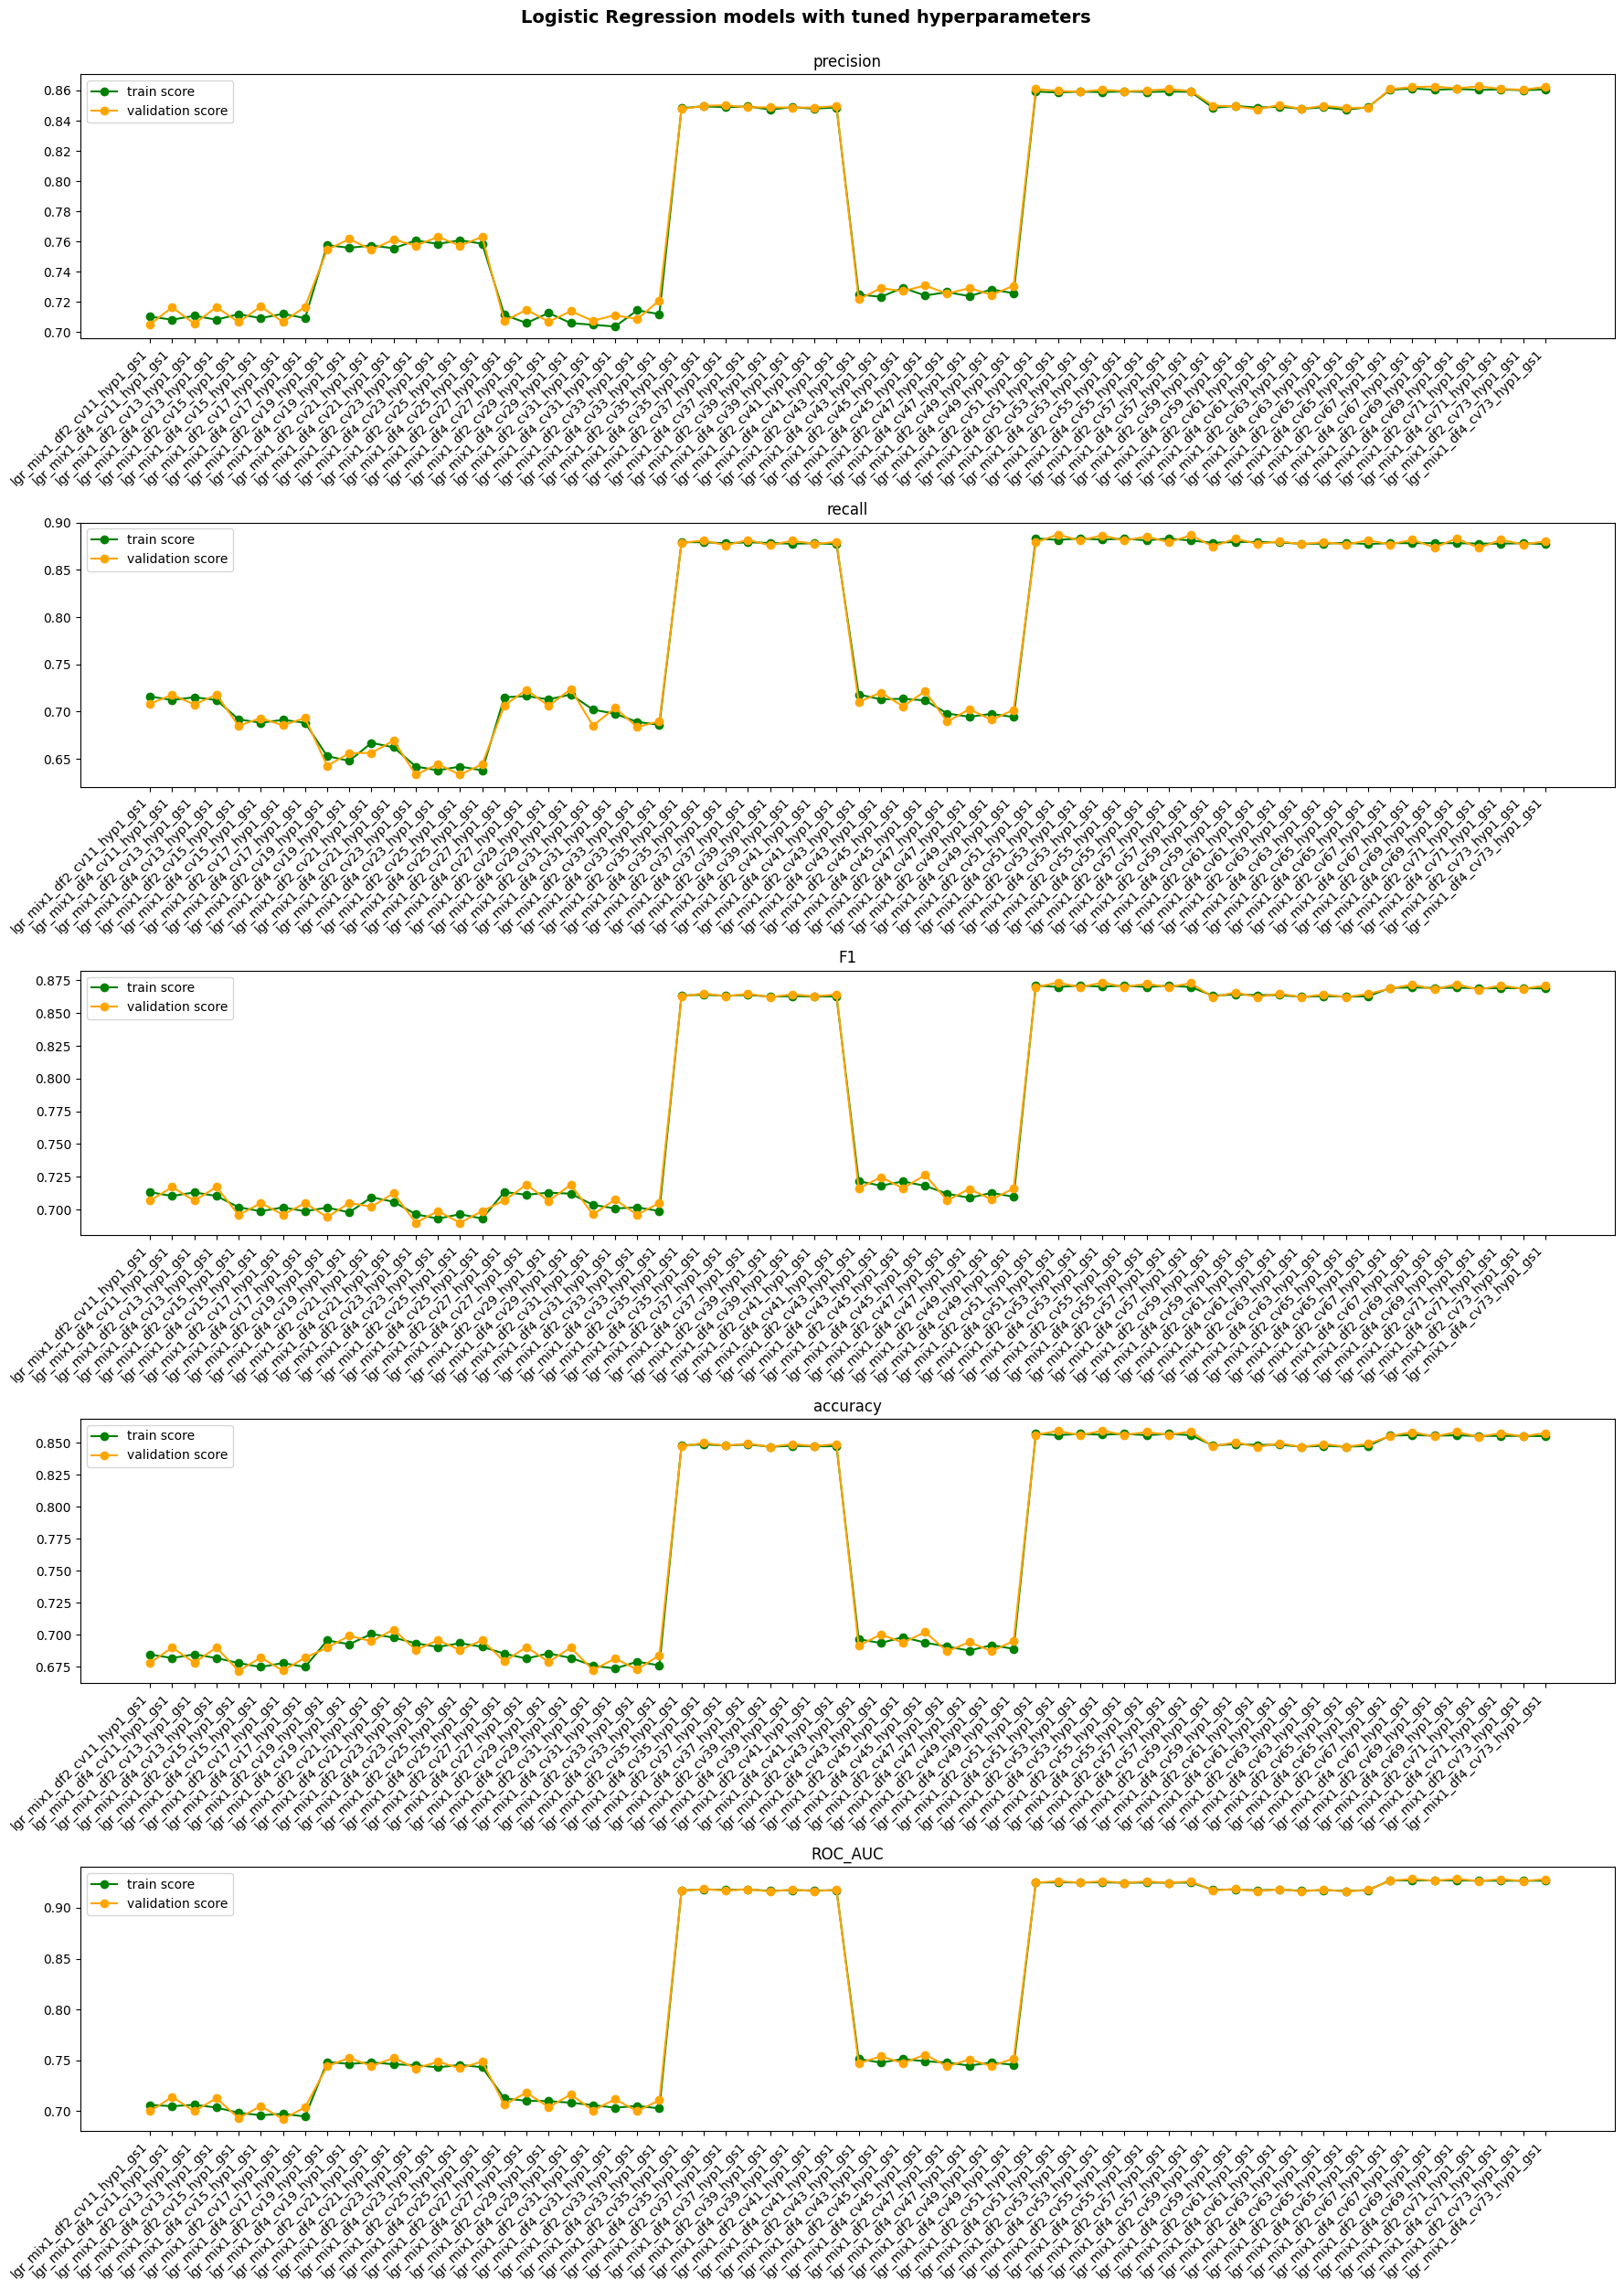

In [62]:
##############################################
#Show Trian and Validation Results
#Scaling
##############################################

fig, axs = plt.subplots(5, 1, figsize=(18,25))

metrics=['precision','recall', 'F1','accuracy','ROC_AUC']

for metric, ax in zip(metrics, axs.ravel()):
    #plot train scores
    ax.plot(lgr_train_score['model'], lgr_train_score[metric], color='green', label='train score',marker='o')
    #plot validation scores
    ax.plot(lgr_val_score['model'], lgr_val_score[metric], color='orange', label='validation score',marker='o')
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend()

plt.suptitle('Logistic Regression models with tuned hyperparameters',y=1,fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

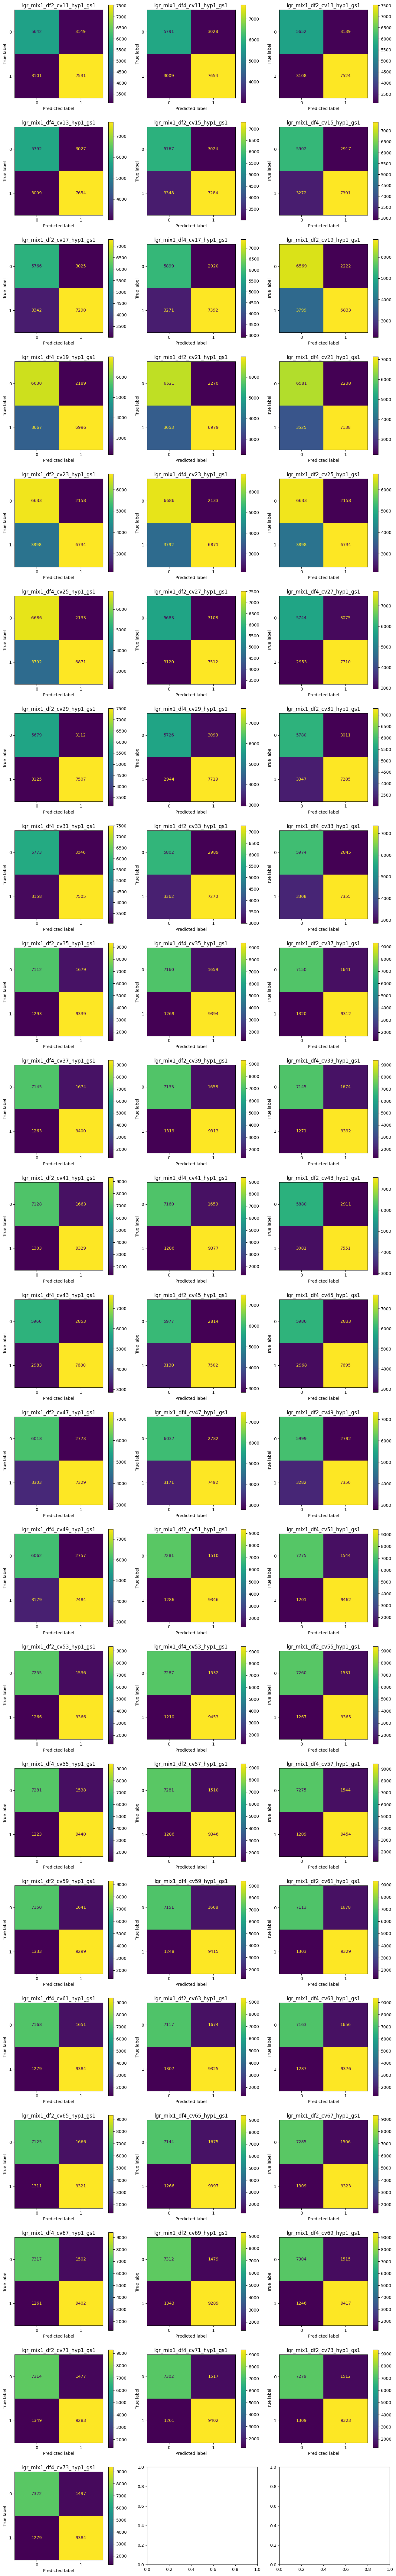

In [63]:
#################################################################################
#Display confusion on validation data
#################################################################################
rowCount=math.ceil(len(lgr_cv_list)/3)
fig, axes = plt.subplots(nrows=rowCount, ncols=3, figsize=(16,rowCount*5))

for lgr_cv,ax,model_index in zip(lgr_cv_list,axes.ravel(),range(len(lgr_cv_list))):
    model=lgr_cv.best_estimator_
    lgr_model_name=lgr_model_name_list[model_index]
    
    params_index=find_number(lgr_model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()
    df_index=find_number(lgr_model_name, '_df')[0]-1
    X_val=X_val_list[df_index]
    y_val=y_val_list[df_index]
    select_features=get_fit_features(select_col,X_val.columns)

    confusion_matrix_plot_ax(model, X_val[select_features], y_val,ax,lgr_model_name)

# Test model on test set

* Select champion model
* Fit all train and validation data
* Validate champion model on test set

### Logistic Regression

In [64]:
%%script True
#########################################################
#Potential Champion model
#########################################################
#get best params
best_model_name='lgr_mix1_df1_cv2_hyp1_gs1'
best_model_index=lgr_model_name_list.index(best_model_name)
best_model=lgr_cv_list[best_model_index]
best_params=best_model.best_params_
#remove classifier__ in resampled model
best_params = {k.replace('classifier__',''):v for k,v in best_params.items()}

#pickle file lgr_[dummy|label]xx_cvXX_hyp*_gs* XX is index
params_index=find_number(best_model_name, '_cv')[0]-1
select_col=select_col_list[params_index].copy()

print(f"best hyperpatameters: {best_params}")
print(f"best features: {select_col}")
print(f"best model name: {best_model_name}")

###################################################
#Fit model and get test score
###################################################
if 'lgr Model name' in best_params:
        best_params.pop('lgr Model name')
lgr_best = LogisticRegression(**best_params,
                                          random_state=RANDOM_STATE)
if 'lgr_mix' in best_model_name:
    target_index=find_number(best_model_name, 'lgr_mix')[0]-1
    df_index=find_number(best_model_name, '_df')[0]-1
    X_train_val=X_train_val_list[df_index]
    y_train_val=y_train_val_list[df_index]
    select_features=get_fit_features(select_col,X_train_val.columns)
    lgr_best.fit(X_train_val[select_features], y_train_val)

    #get test score
    X_test=X_test_list[df_index]
    y_test=y_test_list[df_index]
    lgr_y_preds=lgr_best.predict(X_test[select_features])
    lgr_y_proba= lgr_best.predict_proba(X_test[select_features])
    test_score=get_test_scores(best_model_name, lgr_y_preds, y_test,lgr_y_proba[:,1])
        

lgr_test_score=pd.concat([test_score]).reset_index(drop=True)
lgr_test_score.to_csv('lgr_test_score.csv', index=False, mode='w')
lgr_test_score

Couldn't find program: 'True'


In [65]:
%%script True
###################################################
#Just see all models
###################################################
lgr_all_test_score_list=[]
for lgr_cv, index in zip(lgr_cv_list, range(len(lgr_cv_list))):
    lgr_params=lgr_cv.best_params_
    lgr_model_name=lgr_model_name_list[index]
    #remove classifier__ in resampled model
    lgr_params = {k.replace('classifier__',''):v for k,v in lgr_params.items()}
    if 'lgr Model name' in lgr_params:
        lgr_params.pop('lgr Model name')
    lgr_classifier = LogisticRegression(**lgr_params,
                                          random_state=RANDOM_STATE)
    #pickle file lgr_[dummy|label]_cvXX_hyp*_gs* XX is index
    params_index=find_number(lgr_model_name, '_cv')[0]-1
    select_col=select_col_list[params_index].copy()

    if 'lgr_mix' in lgr_model_name:
        target_index=find_number(lgr_model_name, 'lgr_mix')[0]-1
        df_index=find_number(lgr_model_name, '_df')[0]-1
        X_train_val=X_train_val_list[df_index]
        y_train_val=y_train_val_list[df_index]
        select_features=get_fit_features(select_col,X_train_val.columns)
        lgr_classifier.fit(X_train_val[select_features], y_train_val)

        X_test=X_test_list[df_index]
        y_test=y_test_list[df_index]
        lgr_preds=lgr_classifier.predict(X_test[select_features])
        lgr_preds_proba=lgr_classifier.predict_proba(X_test[select_features])[:, 1]
        test_score=get_test_scores(lgr_model_name, lgr_preds, y_test,lgr_preds_proba)
        
    
    lgr_all_test_score_list.append(test_score)

lgr_all_test_score=pd.concat(lgr_all_test_score_list).reset_index(drop=True)
lgr_all_test_score.to_csv('lgr_all_test_score.csv', index=False)
lgr_all_test_score

Couldn't find program: 'True'


In [66]:
%%script True
#show df1:X_list[0]
lgr_all_test_score[lgr_all_test_score['model'].str.contains('df1')]

Couldn't find program: 'True'


In [67]:
%%script True
#show df2:X_list[1]
lgr_all_test_score[lgr_all_test_score['model'].str.contains('df2')]

Couldn't find program: 'True'


In [68]:
%%script True
#show df3:X_list[2]
lgr_all_test_score[lgr_all_test_score['model'].str.contains('df3')]

Couldn't find program: 'True'


In [69]:
%%script True
#show df3:X_list[3]
lgr_all_test_score[lgr_all_test_score['model'].str.contains('df4')]

Couldn't find program: 'True'


# Conclusion

* Potential Good Models

|Model Features Used|Feature Index|Potential Good Model|
|:-|:-|:-|
|customer_type+age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes|No.2<BR/>No.66-No.73|lgr_mix1_df4_cv67_hyp1_gs1|
|age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes|No.3<BR/>No.58-No.65|lgr_mix1_df4_cv59_hyp1_gs1|
|customer_type+age+class+flight_distance+rating items+departure_delay_in_minutes|No.4<BR/>No.50-No.57|lgr_mix1_df4_cv51_hyp1_gs1|
|customer_type+age+type_of_travel+class+flight_distance+departure_delay_in_minutes|No.5<BR/>No.42-No.49|lgr_mix1_df4_cv45_hyp1_gs1|
|age+class+flight_distance+rating items+departure_delay_in_minutes|No.6<BR/>No.34-No.41|lgr_mix1_df4_cv35_hyp1_gs1|
|age+type_of_travel+class+flight_distance+departure_delay_in_minutes|No.7<BR/>No.26-No.33|lgr_mix1_df4_cv27_hyp1_gs1|
|customer_type+age+class+flight_distance+departure_delay_in_minutes|No.8<BR/>No.18-No.25|lgr_mix1_df4_cv21_hyp1_gs1|
|age+class+flight_distance+departure_delay_in_minutes|No.9<BR/>No.10-No.17|lgr_mix1_df4_cv11_hyp1_gs1|


* Potential Good Model Scores

|model	|dataset|precision	|recall	|F1	|accuracy	|ROC_AUC|
|:-|:-|-:|-:|-:|-:|-:|
|lgr_mix1_df4_cv11_hyp1_gs1|train|	0.708304|	0.712323|	0.710308|	0.681989|	0.704954|
|lgr_mix1_df4_cv11_hyp1_gs1|validation|	0.708304|	0.712323|	0.710308|	0.681989|	0.704954|
|lgr_mix1_df4_cv21_hyp1_gs1|train|	0.755577|	0.662290|	0.705865|	0.697901|	0.746207|
|lgr_mix1_df4_cv21_hyp1_gs1|validation|	0.755577|	0.662290|	0.705865|	0.697901|	0.746207|
|lgr_mix1_df4_cv27_hyp1_gs1|train|	0.706103|	0.716449|	0.711238|	0.681591|	0.710268|
|lgr_mix1_df4_cv27_hyp1_gs1|validation|	0.706103|	0.716449|	0.711238|	0.681591|	0.710268|
|lgr_mix1_df4_cv35_hyp1_gs1|train|	0.849524|	0.879162|	0.864089|	0.848630|	0.918166|
|lgr_mix1_df4_cv35_hyp1_gs1|validation|	0.849524|	0.879162|	0.864089|	0.848630|	0.918166|
|lgr_mix1_df4_cv45_hyp1_gs1|train|	0.724280|	0.711901|	0.718037|	0.693987|	0.749086|
|lgr_mix1_df4_cv45_hyp1_gs1|validation|	0.724280|	0.711901|	0.718037|	0.693987|	0.749086|
|lgr_mix1_df4_cv53_hyp1_gs1|train|	0.858953|	0.881952|	0.870301|	0.856124|	0.925177|
|lgr_mix1_df4_cv53_hyp1_gs1|validation|	0.860537|	0.886523|	0.873337|	0.859255|	0.926167|
|lgr_mix1_df4_cv59_hyp1_gs1|train|	0.849754|	0.879419|	0.864332|	0.848899|	0.918160|
|lgr_mix1_df4_cv59_hyp1_gs1|validation|	0.849754|	0.879419|	0.864332|	0.848899|	0.918160|
|lgr_mix1_df4_cv67_hyp1_gs1|train|	0.861362|	0.878083|	0.869642|	0.855918|	0.927057|
|lgr_mix1_df4_cv67_hyp1_gs1|validation|	0.861362|	0.878083|	0.869642|	0.855918|	0.927057|






In [70]:
potential_models=['lgr_mix1_df4_cv67_hyp1_gs1','lgr_mix1_df4_cv59_hyp1_gs1',
                 'lgr_mix1_df4_cv53_hyp1_gs1','lgr_mix1_df4_cv45_hyp1_gs1',
                 'lgr_mix1_df4_cv35_hyp1_gs1','lgr_mix1_df4_cv27_hyp1_gs1',
                 'lgr_mix1_df4_cv21_hyp1_gs1','lgr_mix1_df4_cv11_hyp1_gs1']
display(lgr_train_score[lgr_train_score['model'].isin(potential_models)])
display(lgr_val_score[lgr_val_score['model'].isin(potential_models)])


,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df4_cv11_hyp1_gs1,0.708304,0.712323,0.710308,0.681989,0.704954
11,lgr_mix1_df4_cv21_hyp1_gs1,0.755577,0.662290,0.705865,0.697901,0.746207
17,lgr_mix1_df4_cv27_hyp1_gs1,0.706103,0.716449,0.711238,0.681591,0.710268
25,lgr_mix1_df4_cv35_hyp1_gs1,0.849524,0.879162,0.864089,0.848630,0.918166
35,lgr_mix1_df4_cv45_hyp1_gs1,0.724280,0.711901,0.718037,0.693987,0.749086
43,lgr_mix1_df4_cv53_hyp1_gs1,0.858953,0.881952,0.870301,0.856124,0.925177
49,lgr_mix1_df4_cv59_hyp1_gs1,0.849754,0.879419,0.864332,0.848899,0.918160
57,lgr_mix1_df4_cv67_hyp1_gs1,0.861362,0.878083,0.869642,0.855918,0.927057


,model,precision,recall,F1,accuracy,ROC_AUC
1,lgr_mix1_df4_cv11_hyp1_gs1,0.716532,0.717809,0.717170,0.690124,0.714004
11,lgr_mix1_df4_cv21_hyp1_gs1,0.761305,0.669418,0.712411,0.704188,0.752415
17,lgr_mix1_df4_cv27_hyp1_gs1,0.714882,0.723061,0.718948,0.690586,0.718296
25,lgr_mix1_df4_cv35_hyp1_gs1,0.849905,0.880990,0.865169,0.849707,0.918523
35,lgr_mix1_df4_cv45_hyp1_gs1,0.730908,0.721654,0.726252,0.702238,0.755580
43,lgr_mix1_df4_cv53_hyp1_gs1,0.860537,0.886523,0.873337,0.859255,0.926167
49,lgr_mix1_df4_cv59_hyp1_gs1,0.849499,0.882960,0.865906,0.850323,0.918533
57,lgr_mix1_df4_cv67_hyp1_gs1,0.862252,0.881741,0.871888,0.858177,0.928508


In [71]:
feature_index_map={
    "customer_type+age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes":
    [2,66,67,68,69,70,71,72,73],
    "age+type_of_travel+class+flight_distance+rating items+departure_delay_in_minutes":
    [3,58,59,60,61,62,63,64,65],
    "customer_type+age+class+flight_distance+rating items+departure_delay_in_minutes":
    [4,50,51,52,53,54,55,56,57],
    "customer_type+age+type_of_travel+class+flight_distance+departure_delay_in_minutes":
    [5,42,43,44,45,46,47,48,49],
    "age+class+flight_distance+rating items+departure_delay_in_minutes":
    [6,34,35,36,37,38,39,40,41],
    "age+type_of_travel+class+flight_distance+departure_delay_in_minutes":
    [7,26,27,28,29,30,31,32,33],
    "customer_type+age+class+flight_distance+departure_delay_in_minutes":
    [8,18,19,20,21,22,23,24,25],
    "age+class+flight_distance+departure_delay_in_minutes":
    [9,10,11,12,13,14,15,16,17]
    
}

lgr_potential_good_models_train=lgr_train_score[lgr_train_score['model'].isin(potential_models)]
lgr_potential_good_models_train['dataset']='train'
lgr_potential_good_models_val=lgr_val_score[lgr_val_score['model'].isin(potential_models)]
lgr_potential_good_models_val['dataset']='validation'
lgr_potential_good_models=pd.concat([lgr_potential_good_models_train,lgr_potential_good_models_val]).reset_index(drop=True)


lgr_potential_good_models['features']=''
lgr_potential_good_models['type']='Logistic Regression'
for features,feature_index in zip(feature_index_map.keys(),feature_index_map.values()):
    lgr_potential_good_models['feature_index']=lgr_potential_good_models['model'].str.extract(r'_cv(\d+)_').astype(int)
    mask=lgr_potential_good_models['feature_index'].isin(feature_index)
    lgr_potential_good_models.loc[mask,'features']=features

new_order = ['type', 'features','feature_index','model','dataset', 'precision', 'recall', 'F1', 'accuracy','ROC_AUC']
lgr_potential_good_models = lgr_potential_good_models[new_order]

# Sorting using the custom order
lgr_potential_good_models['features'] = pd.Categorical(lgr_potential_good_models['features'], categories=feature_index_map.keys(), ordered=True)
lgr_potential_good_models=lgr_potential_good_models.sort_values('features')
lgr_potential_good_models.to_csv('lgr_potential_good_models.csv', index=False)
lgr_potential_good_models

,type,features,feature_index,model,dataset,precision,recall,F1,accuracy,ROC_AUC
7,Logistic Regression,customer_type+age+type_of_travel+class+flight_...,67,lgr_mix1_df4_cv67_hyp1_gs1,train,0.861362,0.878083,0.869642,0.855918,0.927057
15,Logistic Regression,customer_type+age+type_of_travel+class+flight_...,67,lgr_mix1_df4_cv67_hyp1_gs1,validation,0.862252,0.881741,0.871888,0.858177,0.928508
6,Logistic Regression,age+type_of_travel+class+flight_distance+ratin...,59,lgr_mix1_df4_cv59_hyp1_gs1,train,0.849754,0.879419,0.864332,0.848899,0.918160
14,Logistic Regression,age+type_of_travel+class+flight_distance+ratin...,59,lgr_mix1_df4_cv59_hyp1_gs1,validation,0.849499,0.882960,0.865906,0.850323,0.918533
5,Logistic Regression,customer_type+age+class+flight_distance+rating...,53,lgr_mix1_df4_cv53_hyp1_gs1,train,0.858953,0.881952,0.870301,0.856124,0.925177
13,Logistic Regression,customer_type+age+class+flight_distance+rating...,53,lgr_mix1_df4_cv53_hyp1_gs1,validation,0.860537,0.886523,0.873337,0.859255,0.926167
4,Logistic Regression,customer_type+age+type_of_travel+class+flight_...,45,lgr_mix1_df4_cv45_hyp1_gs1,train,0.724280,0.711901,0.718037,0.693987,0.749086
12,Logistic Regression,customer_type+age+type_of_travel+class+flight_...,45,lgr_mix1_df4_cv45_hyp1_gs1,validation,0.730908,0.721654,0.726252,0.702238,0.755580
3,Logistic Regression,age+class+flight_distance+rating items+departu...,35,lgr_mix1_df4_cv35_hyp1_gs1,train,0.849524,0.879162,0.864089,0.848630,0.918166
11,Logistic Regression,age+class+flight_distance+rating items+departu...,35,lgr_mix1_df4_cv35_hyp1_gs1,validation,0.849905,0.880990,0.865169,0.849707,0.918523


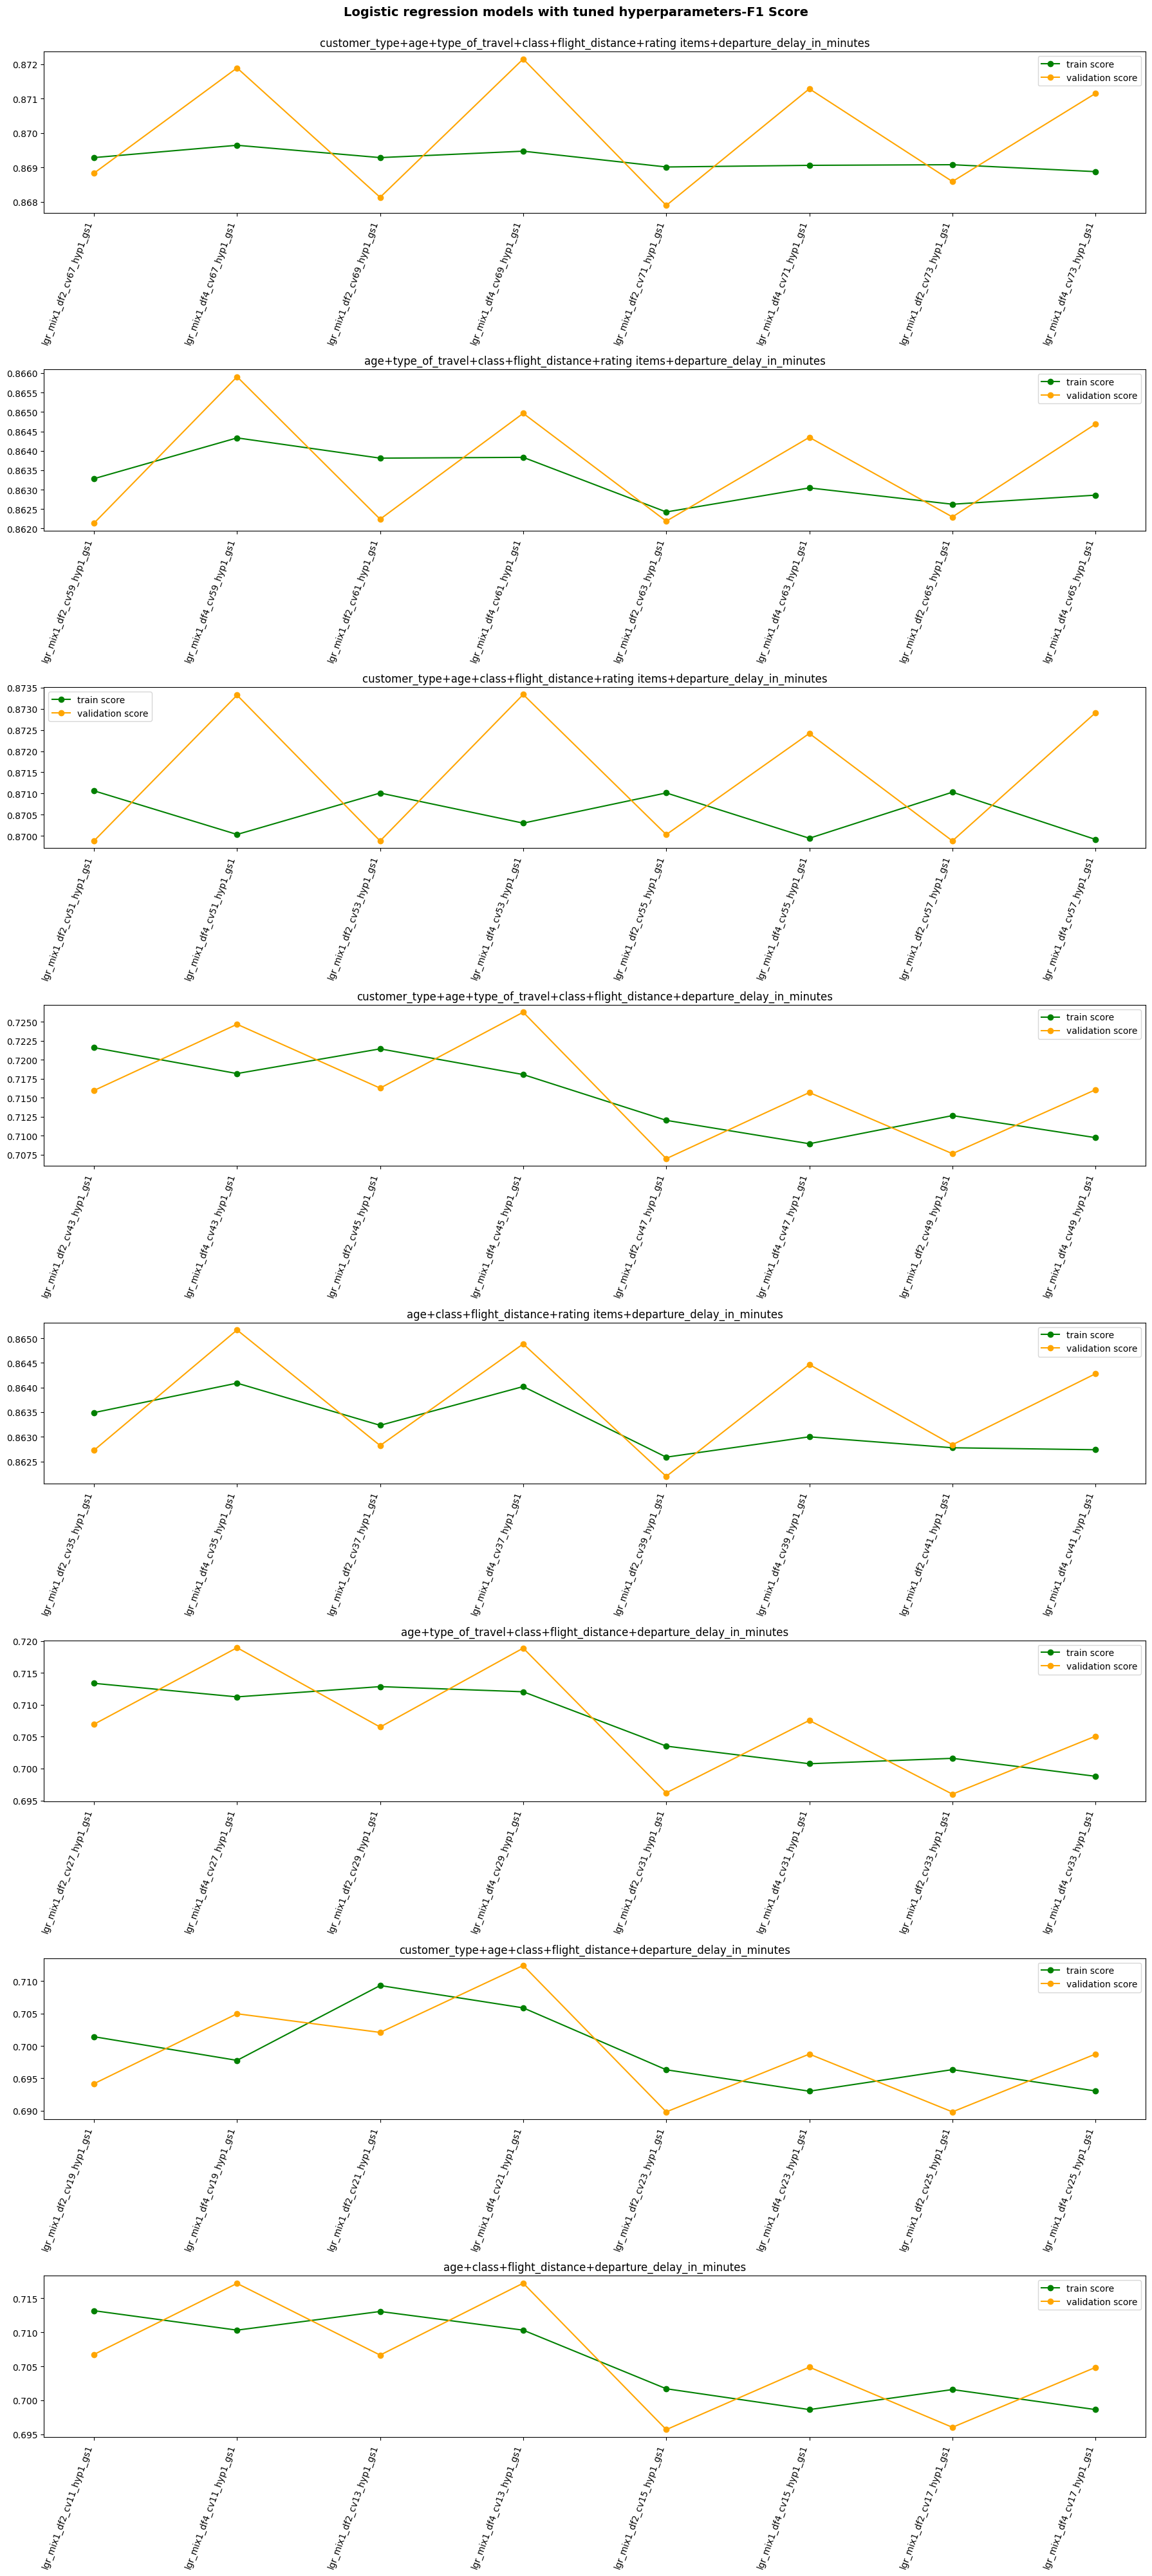

In [72]:
##############################################
#Show Trian and Validation Results
#F1 score
##############################################

fig, axs = plt.subplots(8, 1, figsize=(18,40))

metrics=['precision','recall', 'F1','accuracy','ROC_AUC']


for features,feature_index, ax in zip(feature_index_map.keys(),feature_index_map.values(), axs.ravel()):
    lgr_train_score['feature_index']=lgr_train_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    lgr_val_score['feature_index']=lgr_val_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    mask_train=lgr_train_score['feature_index'].isin(feature_index)
    mask_val=lgr_val_score['feature_index'].isin(feature_index)
    #plot train scores
    ax.plot(lgr_train_score[mask_train]['model'], lgr_train_score[mask_train]['F1'], color='green', label='train score',marker='o')
    #plot validation scores
    ax.plot(lgr_val_score[mask_val]['model'], lgr_val_score[mask_val]['F1'], color='orange', label='validation score',marker='o')
    ax.set_title(features)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=70, ha='right')
    ax.legend()

plt.suptitle('Logistic regression models with tuned hyperparameters-F1 Score',y=1,fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

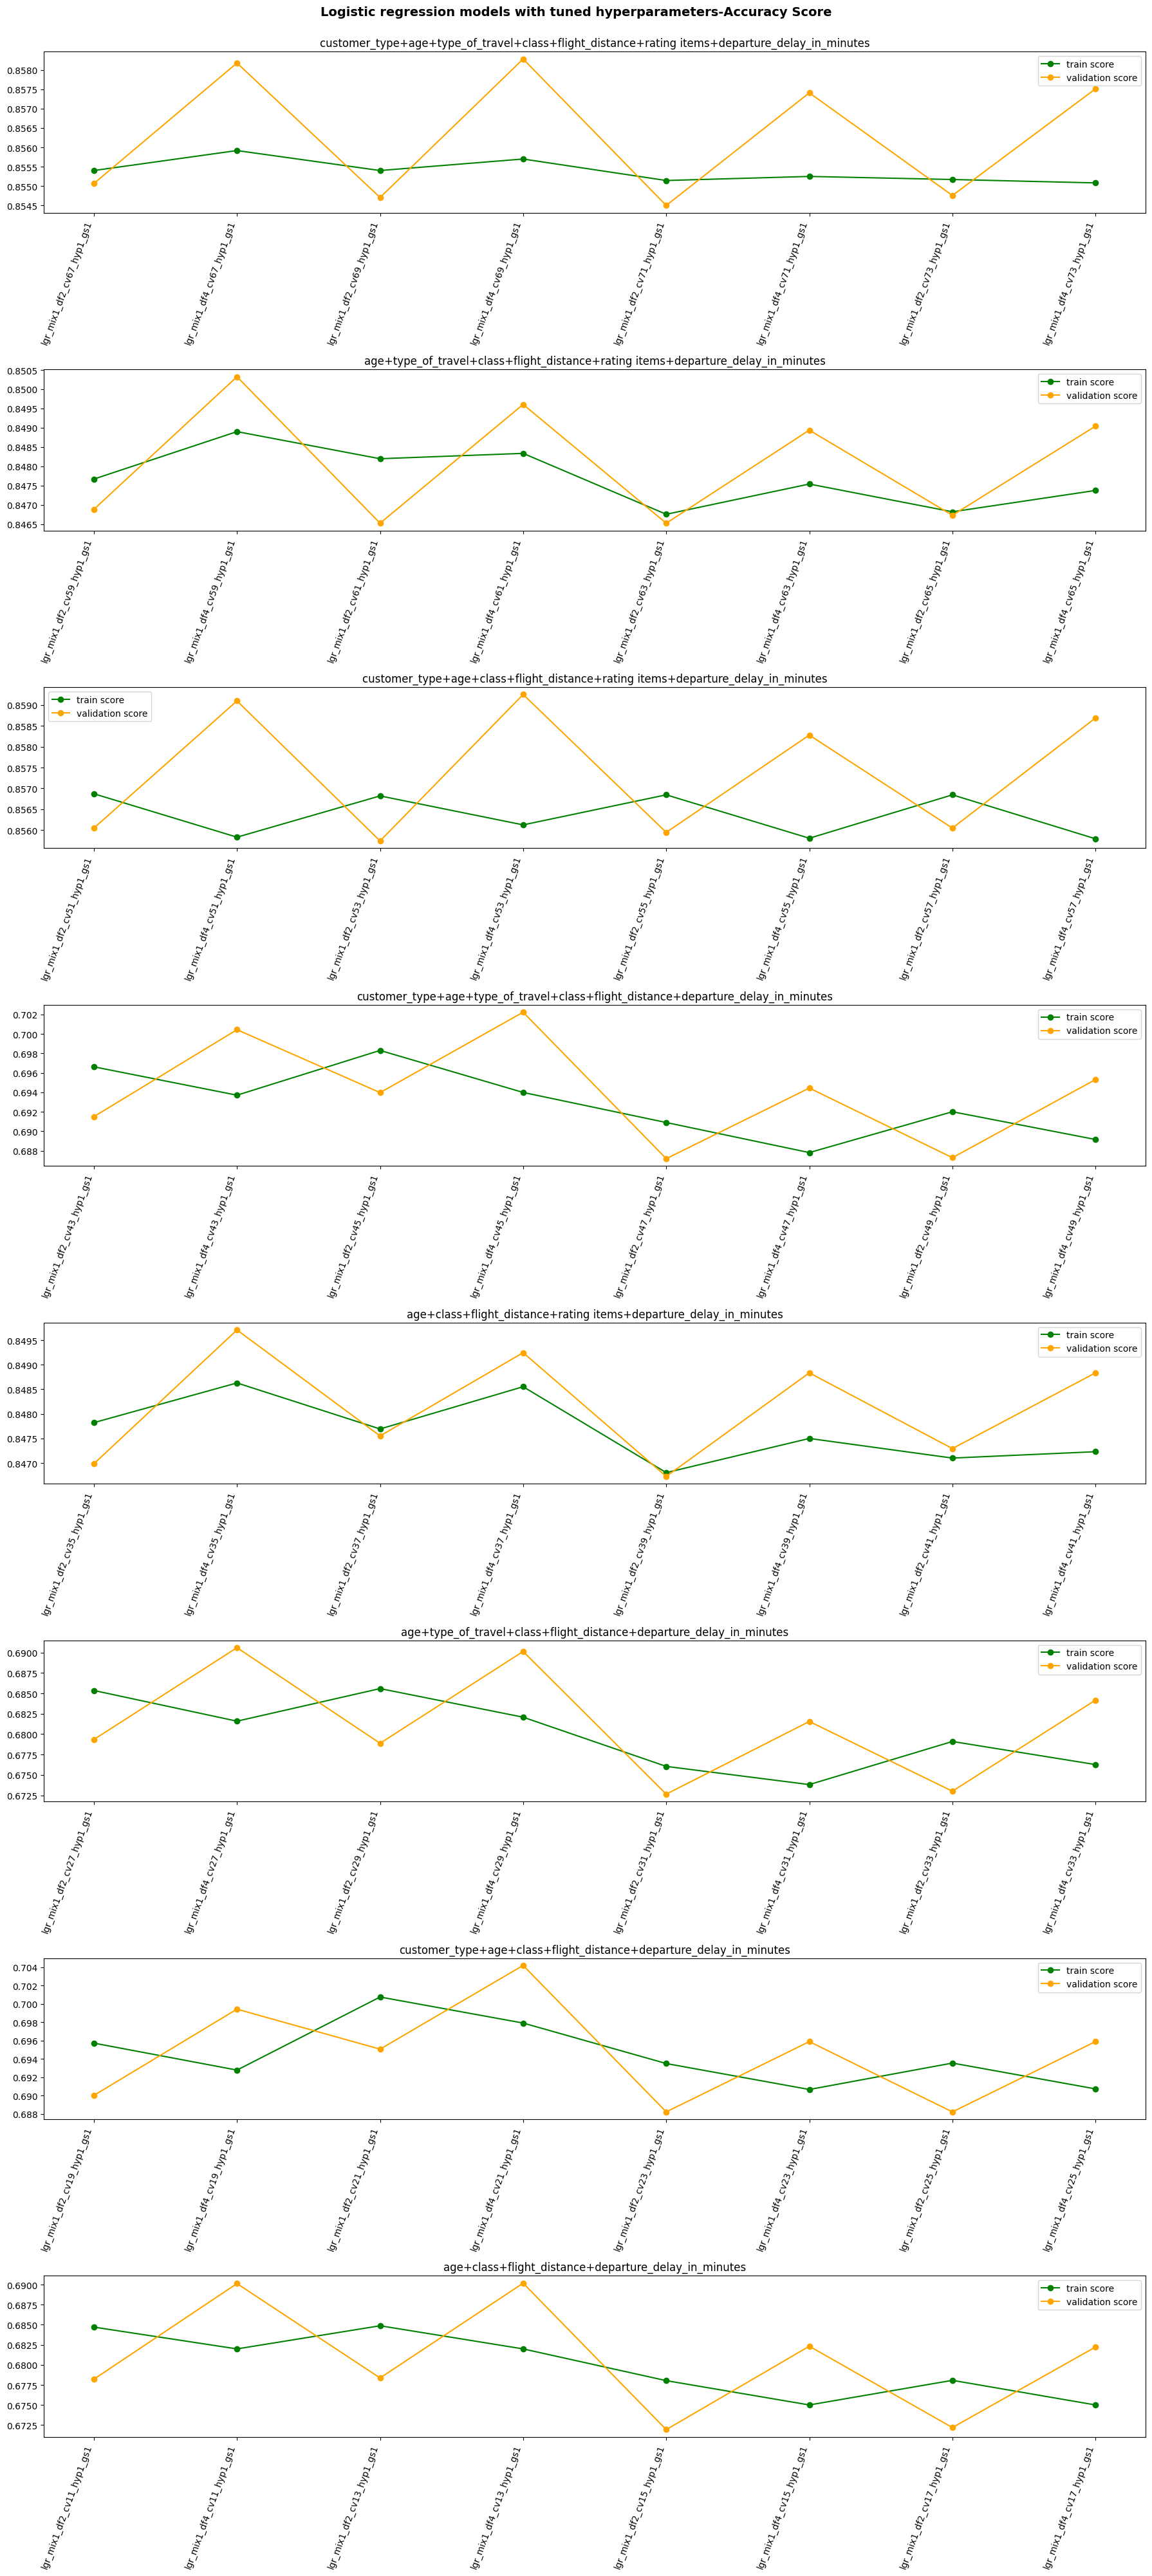

In [73]:
##############################################
#Show Trian and Validation Results
#accuracy score
##############################################

fig, axs = plt.subplots(8, 1, figsize=(18,40))

metrics=['precision','recall', 'F1','accuracy','ROC_AUC']


for features,feature_index, ax in zip(feature_index_map.keys(),feature_index_map.values(), axs.ravel()):
    lgr_train_score['feature_index']=lgr_train_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    lgr_val_score['feature_index']=lgr_val_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    mask_train=lgr_train_score['feature_index'].isin(feature_index)
    mask_val=lgr_val_score['feature_index'].isin(feature_index)
    #plot train scores
    ax.plot(lgr_train_score[mask_train]['model'], lgr_train_score[mask_train]['accuracy'], color='green', label='train score',marker='o')
    #plot validation scores
    ax.plot(lgr_val_score[mask_val]['model'], lgr_val_score[mask_val]['accuracy'], color='orange', label='validation score',marker='o')
    ax.set_title(features)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=70, ha='right')
    ax.legend()

plt.suptitle('Logistic regression models with tuned hyperparameters-Accuracy Score',y=1,fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

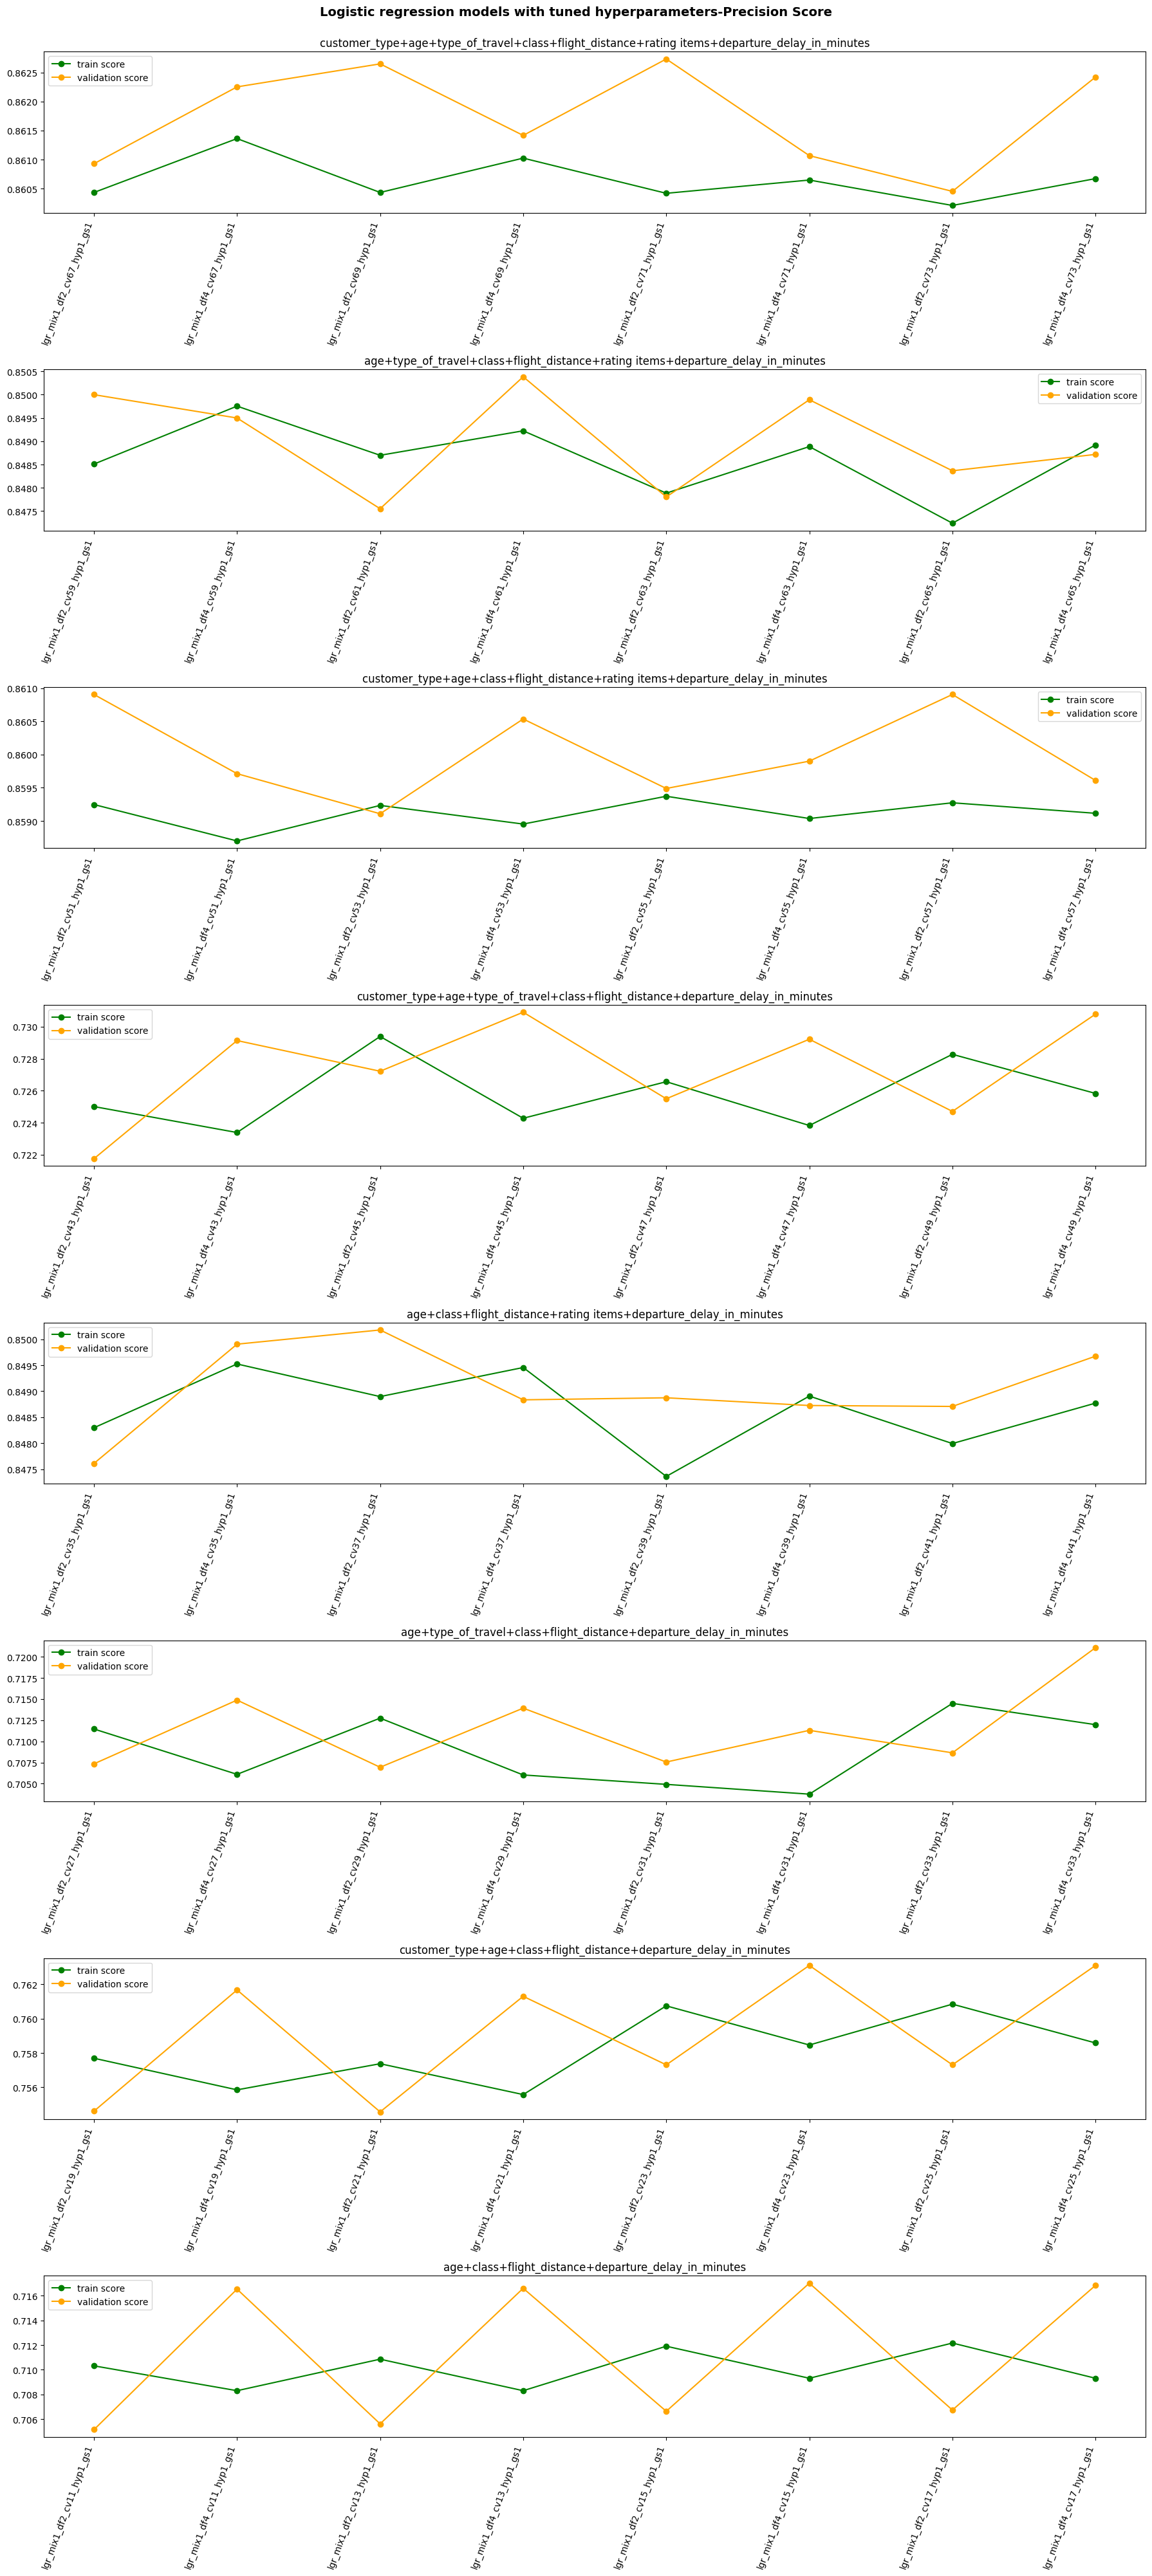

In [74]:
##############################################
#Show Trian and Validation Results
#Precision score
##############################################

fig, axs = plt.subplots(8, 1, figsize=(18,40))

metrics=['precision','recall', 'F1','accuracy','ROC_AUC']


for features,feature_index, ax in zip(feature_index_map.keys(),feature_index_map.values(), axs.ravel()):
    lgr_train_score['feature_index']=lgr_train_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    lgr_val_score['feature_index']=lgr_val_score['model'].str.extract(r'_cv(\d+)_').astype(int)
    mask_train=lgr_train_score['feature_index'].isin(feature_index)
    mask_val=lgr_val_score['feature_index'].isin(feature_index)
    #plot train scores
    ax.plot(lgr_train_score[mask_train]['model'], lgr_train_score[mask_train]['precision'], color='green', label='train score',marker='o')
    #plot validation scores
    ax.plot(lgr_val_score[mask_val]['model'], lgr_val_score[mask_val]['precision'], color='orange', label='validation score',marker='o')
    ax.set_title(features)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=70, ha='right')
    ax.legend()

plt.suptitle('Logistic regression models with tuned hyperparameters-Precision Score',y=1,fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()